<a href="https://colab.research.google.com/github/vitoriaayres/YOLO_TESTES_MARI_INTERFOCUS/blob/main/ROBOFLOW_CAMADAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y pillow PIL
!pip install --no-cache-dir --force-reinstall pillow
!pip install --no-cache-dir --upgrade inference-sdk

In [46]:
!apt-get -qq update
!apt-get -qq install -y libzbar0
!pip -q install --upgrade opencv-contrib-python-headless pyzbar zxing-cpp inference-sdk inference

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [47]:
import math
import io
import re
import shutil
import getpass
from time import perf_counter
from zipfile import BadZipFile, ZipFile
from datetime import datetime
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zxingcpp
from inference_sdk import InferenceConfiguration, InferenceHTTPClient
from google.colab import files
from IPython.display import display
from pyzbar.pyzbar import decode as zbar_decode

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 11

CONFIG = {
    # Resolução usada apenas para localizar candidatos. A decodificação usa o original.
    "detection_max_side": 1800,
    # Filtros geométricos iniciais, ainda não considerados detecções.
    "min_area_ratio": 0.00012,
    "max_area_ratio": 0.12,
    "min_aspect_ratio": 1.8,
    "max_aspect_ratio": 30.0,
    "min_rectangularity": 0.18,
    # Validação do padrão de barras na ROI alinhada.
    "min_edge_runs": 12,
    "min_dark_runs": 9,
    "min_row_transitions": 14,
    "min_valid_row_ratio": 0.58,
    "min_direction_ratio": 1.15,
    "min_signature_score": 0.60,
    # Candidatos mais fracos ainda são recortados e enviados aos decoders.
    "candidate_min_edge_runs": 8,
    "candidate_min_dark_runs": 6,
    "candidate_min_transitions": 10,
    "candidate_min_valid_row_ratio": 0.30,
    "candidate_min_direction_ratio": 1.00,
    "candidate_min_signature_score": 0.42,
    # Sobreposição e margens.
    "nms_iou": 0.25,
    "confirmed_nms_iou": 0.20,
    "confirmed_containment": 0.70,
    "min_retail_symbol_width_ratio": 0.45,
    "validation_margin": 0.04,
    "decode_margin": 0.12,
    # Varredura angular: 0-175 graus cobre todas as orientações de um código 1D.
    "rotation_step_degrees": 5,
    "rotation_max_side": 1200,
    "rotation_candidates_per_angle": 10,
    "rotation_min_votes": 2,
    "rotation_retail_min_votes": 3,
    # Separação física das faixas antes da leitura.
    "band_rotation_step_degrees": 10,
    "band_max_side": 1400,
    "band_candidates_per_angle": 12,
    "band_min_aspect_ratio": 2.2,
    "band_min_width_ratio": 0.045,
    "band_min_height_ratio": 0.006,
    "band_max_height_ratio": 0.16,
    "retail_min_variant_votes": 4,
    # Detector progressivo em camadas: remove iluminação, sombras e textura.
    "layer_rotation_step_degrees": 15,
    "layer_max_side": 1400,
    "layer_candidates_per_angle": 24,
    "layer_response_percentile": 68.0,
    "layer_dark_percentile": 72.0,
    "layer_min_aspect_ratio": 2.0,
    "layer_min_width_ratio": 0.030,
    "layer_min_height_ratio": 0.004,
    "layer_max_height_ratio": 0.14,
    "layer_min_direction_ratio": 1.05,
    "layer_min_edge_runs": 6,
    # Pipeline principal: etiqueta -> perspectiva -> faixas -> leitura.
    "label_max_side": 1600,
    "label_min_area_ratio": 0.018,
    "label_max_area_ratio": 0.82,
    "label_min_aspect_ratio": 1.10,
    "label_max_aspect_ratio": 7.50,
    "label_min_rectangularity": 0.32,
    "label_candidates": 3,
    "strip_candidates_per_orientation": 16,
    "strip_min_height_ratio": 0.004,
    "strip_max_height_ratio": 0.13,
    "strip_min_width_ratio": 0.075,
    "strip_min_aspect_ratio": 1.8,
    "strip_projection_floor": 0.010,
    # ================================================================
    # INÍCIO — CONFIGURAÇÕES DO ROBOFLOW
    # ================================================================
    # True usa o modelo treinado. False executa somente OpenCV/decoders.
    "roboflow_enabled": True,
    # 'local' baixa os pesos uma vez e processa na sessão do Colab.
    # 'hosted' envia cada imagem ao servidor serverless da Roboflow.
    "roboflow_inference_mode": "local",
    # Evita voltar silenciosamente ao modo lento se a carga local falhar.
    "roboflow_hosted_fallback_on_local_error": False,
    # Projeto e versão publicados no Roboflow Universe.
    "roboflow_model_id": "barcode-detector/6",
    # Maior lado da imagem enviada. A leitura posterior usa o original.
    "roboflow_max_side": 1600,
    # Primeiro filtro, aplicado no servidor. Diminuir encontra mais caixas.
    "roboflow_server_confidence": 0.15,
    # Segundo filtro, aplicado localmente. Deve ser >= ao valor acima.
    "roboflow_min_confidence": 0.20,
    # NMS: valor maior preserva mais caixas que se sobrepõem.
    "roboflow_iou_threshold": 0.30,
    # Proteção contra imagens com muitos candidatos.
    "roboflow_max_detections": 50,
    # Quantas das melhores caixas serão realmente enviadas aos decoders.
    "roboflow_candidates_to_decode": 10,
    # ================================================================
    # DESEMPENHO: cascata rápida com parada antecipada.
    "fast_mode": True,
    "fast_crops_per_candidate": 2,
    # As cinco variantes abaixo são as cinco camadas visuais e de leitura.
    "fast_variants_per_crop": 5,
    "fast_strips_per_candidate": 6,
    "fast_label_candidates": 2,
    # Perfil original do Roboflow: modelo -> caixa -> recorte -> decoder.
    # Os três refinamentos abaixo ficam desligados para preservar velocidade.
    "roboflow_split_unresolved_boxes": False,
    "enable_label_fallback": False,
    "enable_opencv_fallback": False,
    # A varredura de muitos ângulos é o estágio mais lento. Ative apenas
    # para investigar imagens que falharam em todos os outros caminhos.
    "enable_angular_fallback": False,
    # PILHA VISUAL: não repete inferência nem decodificação.
    "visual_stack_enabled": True,
    "visual_stack_max_side": 900,
    "visual_layer_max_candidates": 8,
    # Camadas aplicadas de verdade aos recortes antes da leitura.
    "super_resolution_scale": 2.0,
    "super_resolution_target_height": 180,
    "super_resolution_max_scale": 4.0,
    "super_resolution_sharpen": 0.35,
    "contrast_clip_limit": 3.0,
    # FIM — CONFIGURAÇÕES DO ROBOFLOW
    # Presets úteis:
    #   Sensível: server=0.10, min=0.15, iou=0.45
    #   Balanceado (atual): server=0.15, min=0.20, iou=0.30
    #   Rigoroso: server=0.30, min=0.40, iou=0.30
    # ================================================================
}

print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")


def validate_roboflow_config(config=CONFIG):
    server_confidence = float(config["roboflow_server_confidence"])
    local_confidence = float(config["roboflow_min_confidence"])
    iou_threshold = float(config["roboflow_iou_threshold"])
    if not 0.0 <= server_confidence <= 1.0:
        raise ValueError("roboflow_server_confidence deve estar entre 0 e 1.")
    if not 0.0 <= local_confidence <= 1.0:
        raise ValueError("roboflow_min_confidence deve estar entre 0 e 1.")
    if local_confidence < server_confidence:
        raise ValueError(
            "roboflow_min_confidence deve ser maior ou igual a "
            "roboflow_server_confidence."
        )
    if not 0.0 <= iou_threshold <= 1.0:
        raise ValueError("roboflow_iou_threshold deve estar entre 0 e 1.")


def create_roboflow_backend(config=CONFIG):
    if not config["roboflow_enabled"]:
        return None, None, "desativado"
    validate_roboflow_config(config)
    print("\nCONFIGURAÇÕES DO ROBOFLOW ATIVAS")
    print(f"  modelo: {config['roboflow_model_id']}")
    mode = str(config.get("roboflow_inference_mode", "local")).lower()
    if mode not in {"local", "hosted"}:
        raise ValueError("roboflow_inference_mode deve ser 'local' ou 'hosted'.")
    print(f"  execução: {mode}")
    print(f"  confiança inicial: {config['roboflow_server_confidence']:.2f}")
    print(f"  confiança mínima local: {config['roboflow_min_confidence']:.2f}")
    print(f"  IoU/NMS: {config['roboflow_iou_threshold']:.2f}")
    print(f"  resolução máxima enviada: {config['roboflow_max_side']} px")
    print(
        "O detector treinado usa o modelo público "
        f"{config['roboflow_model_id']} do Roboflow Universe."
    )
    api_key = getpass.getpass(
        "Cole sua Private API Key do Roboflow (entrada oculta; Enter desativa): "
    ).strip()
    if not api_key:
        print("Roboflow desativado; nenhuma caixa treinada será produzida.")
        return None, None, "desativado"
    if mode == "local":
        try:
            from inference import get_model
            started = perf_counter()
            model = get_model(
                model_id=config["roboflow_model_id"], api_key=api_key
            )
            elapsed = perf_counter() - started
            print(
                f"Modelo Roboflow local pronto em {elapsed:.1f}s. "
                "A primeira execução baixa os pesos; as próximas usam o cache."
            )
            return model, None, "local"
        except Exception as error:
            allow_hosted = config.get(
                "roboflow_hosted_fallback_on_local_error", False
            )
            destination = (
                "Usando o endpoint hospedado." if allow_hosted else
                "O modo hospedado NÃO será acionado automaticamente."
            )
            print(
                "Não foi possível iniciar a inferência local "
                f"({type(error).__name__}). {destination}"
            )
            if not allow_hosted:
                return None, None, "falha_local"
    client = InferenceHTTPClient(
        api_url="https://serverless.roboflow.com",
        api_key=api_key,
    )
    client.configure(InferenceConfiguration(
        confidence_threshold=config["roboflow_server_confidence"],
        iou_threshold=config["roboflow_iou_threshold"],
        class_filter=["barcode"],
        max_detections=config["roboflow_max_detections"],
        disable_active_learning=True,
        source="barcode_colab_notebook",
    ))
    print("Roboflow hospedado configurado. A chave permanece somente na memória.")
    return None, client, "hosted"


ROBOFLOW_MODEL, ROBOFLOW_CLIENT, ROBOFLOW_BACKEND = create_roboflow_backend(CONFIG)


OpenCV: 5.0.0
NumPy: 2.0.2

CONFIGURAÇÕES DO ROBOFLOW ATIVAS
  modelo: barcode-detector/6
  execução: local
  confiança inicial: 0.15
  confiança mínima local: 0.20
  IoU/NMS: 0.30
  resolução máxima enviada: 1600 px
O detector treinado usa o modelo público barcode-detector/6 do Roboflow Universe.
Cole sua Private API Key do Roboflow (entrada oculta; Enter desativa): ··········


/usr/local/lib/python3.12/dist-packages/inference/core/env.py:240: InferenceDeprecationWarning: CORE_MODEL_GAZE_ENABLED is True: POST /gaze/gaze_detection is registered as a deprecation stub returning HTTP 410 Gone. The stub and this flag will be removed end of Q2 2026. Set CORE_MODEL_GAZE_ENABLED=False to disable it now.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/inference/models/utils.py:564: ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
  warnings.warn(
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", Future

Output()

Modelo Roboflow local pronto em 1.6s. A primeira execução baixa os pesos; as próximas usam o cache.


In [48]:
def odd_size(value, minimum=3, maximum=61):
    value = int(np.clip(round(value), minimum, maximum))
    if value % 2 == 0:
        value += 1 if value < maximum else -1
    return max(3, value)


def order_quad(points):
    points = np.asarray(points, dtype=np.float32)
    ordered = np.zeros((4, 2), dtype=np.float32)
    sums = points.sum(axis=1)
    differences = np.diff(points, axis=1).ravel()
    ordered[0] = points[np.argmin(sums)]       # superior esquerdo
    ordered[1] = points[np.argmin(differences)]  # superior direito
    ordered[2] = points[np.argmax(sums)]       # inferior direito
    ordered[3] = points[np.argmax(differences)]  # inferior esquerdo
    return ordered


def extract_rotated_roi(image, rect, margin_ratio=0.04):
    center, (rect_width, rect_height), angle = rect
    if rect_width <= 1 or rect_height <= 1:
        return None

    expanded = (
        center,
        (
            rect_width * (1.0 + 2.0 * margin_ratio),
            rect_height * (1.0 + 2.0 * margin_ratio),
        ),
        angle,
    )
    source = order_quad(cv2.boxPoints(expanded))
    top_left, top_right, bottom_right, bottom_left = source

    target_width = max(
        2,
        int(round(max(
            np.linalg.norm(top_right - top_left),
            np.linalg.norm(bottom_right - bottom_left),
        ))),
    )
    target_height = max(
        2,
        int(round(max(
            np.linalg.norm(bottom_left - top_left),
            np.linalg.norm(bottom_right - top_right),
        ))),
    )

    destination = np.array(
        [
            [0, 0],
            [target_width - 1, 0],
            [target_width - 1, target_height - 1],
            [0, target_height - 1],
        ],
        dtype=np.float32,
    )
    matrix = cv2.getPerspectiveTransform(source, destination)
    aligned = cv2.warpPerspective(
        image,
        matrix,
        (target_width, target_height),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )

    if aligned.shape[0] > aligned.shape[1]:
        aligned = cv2.rotate(aligned, cv2.ROTATE_90_CLOCKWISE)
    return aligned


def rect_to_bbox(rect, image_shape):
    box = cv2.boxPoints(rect).astype(np.float32)
    height, width = image_shape[:2]
    box[:, 0] = np.clip(box[:, 0], 0, width - 1)
    box[:, 1] = np.clip(box[:, 1], 0, height - 1)
    x, y, w, h = cv2.boundingRect(box.astype(np.int32))
    return box.astype(np.int32), (int(x), int(y), int(w), int(h))


def intersection_over_union(box_a, box_b):
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    left = max(ax, bx)
    top = max(ay, by)
    right = min(ax + aw, bx + bw)
    bottom = min(ay + ah, by + bh)
    intersection = max(0, right - left) * max(0, bottom - top)
    union = aw * ah + bw * bh - intersection
    return intersection / union if union > 0 else 0.0


def count_true_runs(values):
    values = np.asarray(values, dtype=np.uint8).ravel()
    if values.size == 0:
        return 0
    padded = np.pad(values, (1, 1), constant_values=0)
    changes = np.diff(padded.astype(np.int16))
    return int(np.count_nonzero(changes == 1))


In [49]:
def resize_for_detection(image, max_side):
    height, width = image.shape[:2]
    largest = max(height, width)
    if largest <= max_side:
        return image.copy(), 1.0
    scale = max_side / float(largest)
    resized = cv2.resize(
        image,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )
    return resized, scale


def make_barcode_masks(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    normalized = cv2.createCLAHE(
        clipLimit=2.0, tileGridSize=(8, 8)
    ).apply(gray)
    blurred = cv2.GaussianBlur(normalized, (3, 3), 0)

    grad_x = np.abs(cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3))
    grad_y = np.abs(cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3))

    # Barras verticais produzem principalmente gradiente em X.
    response_horizontal = np.maximum(grad_x - 0.55 * grad_y, 0)
    # Barras horizontais, de um código girado, produzem gradiente em Y.
    response_vertical = np.maximum(grad_y - 0.55 * grad_x, 0)

    response_horizontal = cv2.normalize(
        response_horizontal, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)
    response_vertical = cv2.normalize(
        response_vertical, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    response_horizontal = cv2.GaussianBlur(response_horizontal, (3, 3), 0)
    response_vertical = cv2.GaussianBlur(response_vertical, (3, 3), 0)

    _, threshold_horizontal = cv2.threshold(
        response_horizontal, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    _, threshold_vertical = cv2.threshold(
        response_vertical, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    height, width = gray.shape
    reference = min(height, width)
    long_kernel = odd_size(reference * 0.026, 15, 55)
    short_kernel = odd_size(reference * 0.004, 3, 7)

    kernel_horizontal = cv2.getStructuringElement(
        cv2.MORPH_RECT, (long_kernel, short_kernel)
    )
    kernel_vertical = cv2.getStructuringElement(
        cv2.MORPH_RECT, (short_kernel, long_kernel)
    )
    cleanup = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

    mask_horizontal = cv2.morphologyEx(
        threshold_horizontal, cv2.MORPH_CLOSE, kernel_horizontal
    )
    mask_vertical = cv2.morphologyEx(
        threshold_vertical, cv2.MORPH_CLOSE, kernel_vertical
    )
    mask_horizontal = cv2.morphologyEx(
        mask_horizontal, cv2.MORPH_OPEN, cleanup
    )
    mask_vertical = cv2.morphologyEx(
        mask_vertical, cv2.MORPH_OPEN, cleanup
    )

    return {
        "gray": gray,
        "normalized": normalized,
        "response_horizontal": response_horizontal,
        "response_vertical": response_vertical,
        "threshold_horizontal": threshold_horizontal,
        "threshold_vertical": threshold_vertical,
        "mask_horizontal": mask_horizontal,
        "mask_vertical": mask_vertical,
    }


In [50]:
def barcode_signature(roi, config=CONFIG):
    rejected = {
        "accepted": False,
        "score": 0.0,
        "edge_runs": 0,
        "dark_runs": 0,
        "median_transitions": 0.0,
        "valid_row_ratio": 0.0,
        "direction_ratio": 0.0,
    }
    if roi is None or roi.size == 0:
        return rejected

    if roi.ndim == 3:
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    else:
        gray = roi.copy()
    if gray.shape[0] > gray.shape[1]:
        gray = cv2.rotate(gray, cv2.ROTATE_90_CLOCKWISE)

    height, width = gray.shape
    if height < 10 or width < 45 or width / max(height, 1) < 1.5:
        return rejected

    normalized = cv2.createCLAHE(
        clipLimit=2.0, tileGridSize=(8, 8)
    ).apply(gray)
    normalized = cv2.GaussianBlur(normalized, (3, 3), 0)

    gx = np.abs(cv2.Sobel(normalized, cv2.CV_32F, 1, 0, ksize=3))
    gy = np.abs(cv2.Sobel(normalized, cv2.CV_32F, 0, 1, ksize=3))
    direction_ratio = float((gx.mean() + 1.0) / (gy.mean() + 1.0))

    nonzero_edges = gx[gx > 0]
    if nonzero_edges.size == 0:
        return rejected
    edge_threshold = max(18.0, float(np.percentile(nonzero_edges, 68)))
    edge_map = gx >= edge_threshold

    # Uma borda de barra deve existir em uma fração relevante da altura.
    column_coverage = edge_map.mean(axis=0)
    strong_edge_columns = column_coverage >= 0.28
    edge_runs = count_true_runs(strong_edge_columns)

    _, binary = cv2.threshold(
        normalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    dark = binary == 0

    # Barras escuras formam colunas contínuas; letras normalmente não.
    dark_column_coverage = dark.mean(axis=0)
    strong_dark_columns = dark_column_coverage >= 0.55
    dark_runs = count_true_runs(strong_dark_columns)

    # Um barcode mantém muitas transições ao longo de várias linhas.
    row_transitions = np.count_nonzero(
        dark[:, 1:] != dark[:, :-1], axis=1
    ).astype(np.float32)
    trim = max(1, int(round(height * 0.06)))
    central_rows = row_transitions[trim:height - trim]
    if central_rows.size == 0:
        central_rows = row_transitions
    median_transitions = float(np.median(central_rows))
    valid_row_ratio = float(np.mean(
        central_rows >= config["min_row_transitions"]
    ))

    edge_component = min(edge_runs / 24.0, 1.0)
    dark_component = min(dark_runs / 18.0, 1.0)
    transition_component = min(median_transitions / 32.0, 1.0)
    row_component = min(valid_row_ratio / 0.80, 1.0)
    direction_component = min(max(direction_ratio - 0.8, 0.0) / 1.2, 1.0)
    score = float(
        0.24 * edge_component
        + 0.22 * dark_component
        + 0.20 * transition_component
        + 0.22 * row_component
        + 0.12 * direction_component
    )

    accepted = bool(
        edge_runs >= config["min_edge_runs"]
        and dark_runs >= config["min_dark_runs"]
        and median_transitions >= config["min_row_transitions"]
        and valid_row_ratio >= config["min_valid_row_ratio"]
        and direction_ratio >= config["min_direction_ratio"]
        and score >= config["min_signature_score"]
    )

    return {
        "accepted": accepted,
        "score": score,
        "edge_runs": int(edge_runs),
        "dark_runs": int(dark_runs),
        "median_transitions": median_transitions,
        "valid_row_ratio": valid_row_ratio,
        "direction_ratio": direction_ratio,
    }


def has_barcode_potential(signature, config=CONFIG):
    # O decoder decide o resultado final. Esta etapa só evita perder barras reais
    # pouco contrastadas, pequenas ou próximas de outros códigos.
    return bool(
        signature["accepted"]
        or (
            signature["edge_runs"] >= config["candidate_min_edge_runs"]
            and signature["dark_runs"] >= config["candidate_min_dark_runs"]
            and signature["median_transitions"]
            >= config["candidate_min_transitions"]
            and signature["valid_row_ratio"]
            >= config["candidate_min_valid_row_ratio"]
            and signature["direction_ratio"]
            >= config["candidate_min_direction_ratio"]
            and signature["score"]
            >= config["candidate_min_signature_score"]
        )
    )


In [51]:
def geometric_candidates(mask, image_shape, orientation, config=CONFIG):
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    image_height, image_width = image_shape[:2]
    image_area = image_height * image_width
    reference = min(image_height, image_width)
    minimum_long_side = max(35.0, reference * 0.025)
    minimum_short_side = max(7.0, reference * 0.006)

    proposals = []
    for contour in contours:
        contour_area = float(cv2.contourArea(contour))
        if contour_area <= 0:
            continue
        rect = cv2.minAreaRect(contour)
        rect_width, rect_height = rect[1]
        if rect_width <= 1 or rect_height <= 1:
            continue

        long_side = max(rect_width, rect_height)
        short_side = min(rect_width, rect_height)
        aspect_ratio = long_side / max(short_side, 1.0)
        rect_area = rect_width * rect_height
        area_ratio = rect_area / image_area
        rectangularity = contour_area / max(rect_area, 1.0)

        if not (
            config["min_area_ratio"] <= area_ratio <= config["max_area_ratio"]
            and config["min_aspect_ratio"] <= aspect_ratio <= config["max_aspect_ratio"]
            and rectangularity >= config["min_rectangularity"]
            and long_side >= minimum_long_side
            and short_side >= minimum_short_side
        ):
            continue

        box, bbox = rect_to_bbox(rect, image_shape)
        proposals.append({
            "rect": rect,
            "box": box,
            "bbox": bbox,
            "orientation": orientation,
            "area_ratio": float(area_ratio),
            "aspect_ratio": float(aspect_ratio),
            "rectangularity": float(rectangularity),
        })
    return proposals


def scale_rect(rect, factor):
    center, size, angle = rect
    return (
        (center[0] * factor, center[1] * factor),
        (size[0] * factor, size[1] * factor),
        angle,
    )


def locate_bar_regions(image, config=CONFIG, return_steps=False):
    if image is None or not isinstance(image, np.ndarray) or image.size == 0:
        raise ValueError("A imagem fornecida é inválida.")
    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("Use uma imagem BGR com três canais.")

    working, scale = resize_for_detection(
        image, config["detection_max_side"]
    )
    steps = make_barcode_masks(working)

    proposals = []
    proposals.extend(geometric_candidates(
        steps["mask_horizontal"], working.shape, "horizontal", config
    ))
    proposals.extend(geometric_candidates(
        steps["mask_vertical"], working.shape, "vertical", config
    ))

    validated = []
    for proposal in proposals:
        validation_roi = extract_rotated_roi(
            working,
            proposal["rect"],
            config["validation_margin"],
        )
        signature = barcode_signature(validation_roi, config)
        if not has_barcode_potential(signature, config):
            continue
        proposal = dict(proposal)
        proposal["signature"] = signature
        proposal["ranking_score"] = float(
            signature["score"]
            + 0.08 * min(proposal["aspect_ratio"] / 8.0, 1.0)
            + 0.04 * proposal["rectangularity"]
        )
        validated.append(proposal)

    validated.sort(key=lambda item: item["ranking_score"], reverse=True)
    selected = []
    for proposal in validated:
        if all(
            intersection_over_union(proposal["bbox"], kept["bbox"])
            < config["nms_iou"]
            for kept in selected
        ):
            selected.append(proposal)

    # Volta às coordenadas da imagem original e revalida em resolução cheia.
    factor = 1.0 / scale
    results = []
    for proposal in selected:
        original_rect = scale_rect(proposal["rect"], factor)
        tight_roi = extract_rotated_roi(
            image, original_rect, config["validation_margin"]
        )
        full_signature = barcode_signature(tight_roi, config)
        if not has_barcode_potential(full_signature, config):
            continue

        decode_roi = extract_rotated_roi(
            image, original_rect, config["decode_margin"]
        )
        box, bbox = rect_to_bbox(original_rect, image.shape)
        results.append({
            "rect": original_rect,
            "box": box,
            "bbox": bbox,
            "orientation": proposal["orientation"],
            "signature": full_signature,
            "tight_roi": tight_roi,
            "decode_roi": decode_roi,
        })

    results.sort(key=lambda item: (item["bbox"][1], item["bbox"][0]))
    for index, result in enumerate(results, start=1):
        result["barcode_id"] = index

    if return_steps:
        return results, steps, scale, len(proposals)
    return results


In [52]:
def text_value(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace").strip()
    if isinstance(value, str):
        return value.strip()
    if isinstance(value, (list, tuple)):
        for item in value:
            result = text_value(item)
            if result:
                return result
    if isinstance(value, np.ndarray) and value.dtype.kind in {"U", "S", "O"}:
        for item in value.ravel().tolist():
            result = text_value(item)
            if result:
                return result
    return ""


def decode_opencv(image):
    detector_class = getattr(cv2, "barcode_BarcodeDetector", None)
    if detector_class is None and hasattr(cv2, "barcode"):
        detector_class = getattr(cv2.barcode, "BarcodeDetector", None)
    if detector_class is None:
        return None

    detector = detector_class()
    for method_name in ("detectAndDecodeWithType", "detectAndDecode"):
        method = getattr(detector, method_name, None)
        if method is None:
            continue
        try:
            output = method(image)
        except (cv2.error, TypeError):
            continue
        if not isinstance(output, tuple):
            continue

        if len(output) == 4:
            value = text_value(output[1])
            barcode_type = text_value(output[2])
            points = output[3]
        elif len(output) == 3:
            value = text_value(output[0])
            barcode_type = ""
            points = output[2]
        else:
            continue
        symbol_width_ratio = 1.0
        try:
            point_array = np.asarray(points, dtype=np.float32).reshape(-1, 2)
            if point_array.size:
                symbol_width_ratio = float(
                    (point_array[:, 0].max() - point_array[:, 0].min())
                    / max(image.shape[1], 1)
                )
        except (TypeError, ValueError):
            pass
        if value:
            return {
                "decoded": True,
                "value": value,
                "type": barcode_type or "OpenCV",
                "decoder": "OpenCV",
                "symbol_width_ratio": symbol_width_ratio,
            }
    return None


def decode_pyzbar(image):
    try:
        items = zbar_decode(image)
    except Exception:
        return None
    if not items:
        return None
    item = items[0]
    symbol_width_ratio = float(item.rect.width / max(image.shape[1], 1))
    return {
        "decoded": True,
        "value": item.data.decode("utf-8", errors="replace"),
        "type": item.type or "ZBar",
        "decoder": "pyzbar",
        "symbol_width_ratio": symbol_width_ratio,
    }


def decode_zxing(image):
    try:
        items = zxingcpp.read_barcodes(
            image, try_rotate=True, try_downscale=True, try_invert=True
        )
    except Exception:
        return None
    if not items:
        return None
    item = items[0]
    value = str(item.text).strip()
    if not item.valid or not value:
        return None
    position = item.position
    xs = [
        position.top_left.x, position.top_right.x,
        position.bottom_right.x, position.bottom_left.x,
    ]
    symbol_width_ratio = float((max(xs) - min(xs)) / max(image.shape[1], 1))
    return {
        "decoded": True,
        "value": value,
        "type": str(item.format),
        "decoder": "ZXing-C++",
        "symbol_width_ratio": symbol_width_ratio,
    }


def decode_validated_roi(roi):
    if roi is None or roi.size == 0:
        return {
            "decoded": False,
            "value": "",
            "type": "Não identificado",
            "decoder": "Nenhum",
            "variant": "Nenhuma",
        }

    height, width = roi.shape[:2]
    pad_y = max(12, int(round(height * 0.22)))
    pad_x = max(24, int(round(width * 0.08)))
    padded = cv2.copyMakeBorder(
        roi,
        pad_y,
        pad_y,
        pad_x,
        pad_x,
        cv2.BORDER_CONSTANT,
        value=(255, 255, 255),
    )

    gray = cv2.cvtColor(padded, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    _, otsu = cv2.threshold(
        clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    scale = float(np.clip(180.0 / max(height, 1), 2.0, 5.0))
    enlarged_gray = cv2.resize(
        clahe, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC
    )
    enlarged_binary = cv2.resize(
        otsu, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST
    )
    sharpened = cv2.filter2D(
        enlarged_gray,
        -1,
        np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32),
    )

    variants = [
        ("ROI com zona branca", padded),
        ("Escala de cinza", gray),
        ("Contraste local", clahe),
        ("Otsu", otsu),
        ("Ampliada", enlarged_gray),
        ("Ampliada binária", enlarged_binary),
        ("Nitidez", sharpened),
    ]

    # ZXing-C++ é tentado primeiro por ser mais robusto em recortes pequenos.
    for name, variant in variants:
        result = decode_zxing(variant)
        if result:
            result["variant"] = name
            return result
    # ZBar fornece uma segunda implementação para Code 128 e outros formatos 1D.
    for name, variant in variants:
        result = decode_pyzbar(variant)
        if result:
            result["variant"] = name
            return result
    for name, variant in variants:
        result = decode_opencv(variant)
        if result:
            result["variant"] = name
            return result

    return {
        "decoded": False,
        "value": "",
        "type": "Não identificado",
        "decoder": "Nenhum",
        "variant": "Nenhuma",
    }


def decode_regions(regions):
    for region in regions:
        # Primeiro corta somente as barras. A margem maior é apenas fallback.
        attempts = [
            ("Recorte isolado", region["tight_roi"]),
            ("Recorte com margem", region["decode_roi"]),
        ]
        final_result = None
        for crop_name, crop in attempts:
            result = decode_validated_roi(crop)
            if result["decoded"]:
                result["crop"] = crop_name
                final_result = result
                break
        if final_result is None:
            final_result = decode_validated_roi(region["decode_roi"])
            final_result["crop"] = "Nenhum"
        region.update(final_result)
    return regions


def decode_zxing_full_image_regions(image, config=CONFIG):
    # Uma leitura global preserva códigos próximos como símbolos independentes.
    try:
        items = zxingcpp.read_barcodes(
            image, try_rotate=True, try_downscale=True, try_invert=True
        )
    except Exception:
        return []

    regions = []
    for item in items:
        value = str(item.text).strip()
        if not item.valid or not value:
            continue
        position = item.position
        points = np.array([
            [position.top_left.x, position.top_left.y],
            [position.top_right.x, position.top_right.y],
            [position.bottom_right.x, position.bottom_right.y],
            [position.bottom_left.x, position.bottom_left.y],
        ], dtype=np.float32)
        rect = cv2.minAreaRect(points)
        rect_width, rect_height = rect[1]
        if max(rect_width, rect_height) < 12:
            continue
        if min(rect_width, rect_height) < 6:
            # Alguns leitores retornam uma linha central para símbolos 1D.
            long_side = max(rect_width, rect_height)
            short_side = max(12.0, long_side * 0.12)
            if rect_width >= rect_height:
                rect = (rect[0], (long_side, short_side), rect[2])
            else:
                rect = (rect[0], (short_side, long_side), rect[2])

        tight_roi = extract_rotated_roi(image, rect, config["validation_margin"])
        decode_roi = extract_rotated_roi(image, rect, config["decode_margin"])
        signature = barcode_signature(tight_roi, config)
        signature = dict(signature)
        signature["accepted"] = True
        signature["score"] = max(signature["score"], 0.95)
        box, bbox = rect_to_bbox(rect, image.shape)
        regions.append({
            "rect": rect,
            "box": box,
            "bbox": bbox,
            "orientation": "ZXing imagem completa",
            "signature": signature,
            "tight_roi": tight_roi,
            "decode_roi": decode_roi,
            "decoded": True,
            "value": value,
            "type": str(item.format),
            "decoder": "ZXing-C++",
            "variant": "Imagem completa",
            "crop": "Polígono do decoder",
            "symbol_width_ratio": 1.0,
        })
    return regions


def rotate_image_without_clipping(image, angle_degrees):
    height, width = image.shape[:2]
    center = (width / 2.0, height / 2.0)
    matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0)
    cosine = abs(matrix[0, 0])
    sine = abs(matrix[0, 1])
    rotated_width = int(math.ceil(height * sine + width * cosine))
    rotated_height = int(math.ceil(height * cosine + width * sine))
    matrix[0, 2] += rotated_width / 2.0 - center[0]
    matrix[1, 2] += rotated_height / 2.0 - center[1]
    rotated = cv2.warpAffine(
        image, matrix, (rotated_width, rotated_height),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )
    return rotated, matrix


def map_rotated_rect_to_original(
    rect, rotation_matrix, detection_scale, original_shape
):
    rotated_points = cv2.boxPoints(rect).astype(np.float32)
    inverse_matrix = cv2.invertAffineTransform(rotation_matrix)
    base_points = cv2.transform(
        rotated_points.reshape(1, -1, 2), inverse_matrix
    )[0]
    original_points = base_points / max(detection_scale, 1e-8)
    height, width = original_shape[:2]
    original_points[:, 0] = np.clip(original_points[:, 0], 0, width - 1)
    original_points[:, 1] = np.clip(original_points[:, 1], 0, height - 1)
    return cv2.minAreaRect(original_points.astype(np.float32))


def decoded_crop_at_angle(
    rotated_image, proposal, angle, rotation_matrix,
    detection_scale, original_image, config=CONFIG,
):
    tight_roi = extract_rotated_roi(
        rotated_image, proposal["rect"], config["validation_margin"]
    )
    signature = barcode_signature(tight_roi, config)
    if not has_barcode_potential(signature, config):
        return None

    decode_roi = extract_rotated_roi(
        rotated_image, proposal["rect"], config["decode_margin"]
    )
    result = None
    for crop_name, crop in (
        ("Recorte angular isolado", tight_roi),
        ("Recorte angular com margem", decode_roi),
    ):
        attempt = decode_validated_roi(crop)
        if attempt["decoded"]:
            attempt["crop"] = crop_name
            result = attempt
            break
    if result is None:
        return None

    original_rect = map_rotated_rect_to_original(
        proposal["rect"], rotation_matrix, detection_scale,
        original_image.shape,
    )
    box, bbox = rect_to_bbox(original_rect, original_image.shape)
    region = {
        "rect": original_rect,
        "box": box,
        "bbox": bbox,
        "orientation": f"varredura {angle} graus",
        "signature": signature,
        "tight_roi": tight_roi,
        "decode_roi": decode_roi,
        "sweep_angle": int(angle),
        "source": "recorte angular",
    }
    region.update(result)
    return region


def angular_sweep_barcode_regions(image, config=CONFIG):
    base_image, detection_scale = resize_for_detection(
        image, config["rotation_max_side"]
    )
    step = max(1, int(config["rotation_step_degrees"]))
    angles = list(range(0, 180, step))
    readings = []
    angle_stats = []

    for angle in angles:
        print(
            f"Varredura angular: {angle:3d} graus "
            f"({angles.index(angle) + 1}/{len(angles)})",
            end="\r",
        )
        rotated, rotation_matrix = rotate_image_without_clipping(
            base_image, angle
        )
        steps = make_barcode_masks(rotated)
        proposals = geometric_candidates(
            steps["mask_horizontal"], rotated.shape,
            f"angular_{angle}", config,
        )

        ranked = []
        for proposal in proposals:
            roi = extract_rotated_roi(
                rotated, proposal["rect"], config["validation_margin"]
            )
            signature = barcode_signature(roi, config)
            if not has_barcode_potential(signature, config):
                continue
            proposal = dict(proposal)
            proposal["angular_rank"] = (
                signature["score"]
                + 0.04 * min(proposal["aspect_ratio"] / 8.0, 1.0)
                + 0.02 * proposal["rectangularity"]
            )
            ranked.append(proposal)

        ranked.sort(key=lambda item: item["angular_rank"], reverse=True)
        ranked = ranked[:config["rotation_candidates_per_angle"]]
        decoded_count = 0
        for proposal in ranked:
            region = decoded_crop_at_angle(
                rotated, proposal, angle, rotation_matrix,
                detection_scale, image, config,
            )
            if region is None or not is_confirmed_1d_barcode(region):
                continue
            readings.append(region)
            decoded_count += 1

        # O ZXing também vê a imagem inteira já reamostrada neste ângulo.
        direct = decode_zxing_full_image_regions(rotated, config)
        for region in direct:
            original_rect = map_rotated_rect_to_original(
                region["rect"], rotation_matrix, detection_scale,
                image.shape,
            )
            box, bbox = rect_to_bbox(original_rect, image.shape)
            mapped = dict(region)
            mapped.update({
                "rect": original_rect,
                "box": box,
                "bbox": bbox,
                "orientation": f"ZXing varredura {angle} graus",
                "sweep_angle": int(angle),
                "source": "imagem angular completa",
            })
            if is_confirmed_1d_barcode(mapped):
                readings.append(mapped)
                decoded_count += 1

        angle_stats.append({
            "angulo": angle,
            "propostas": len(proposals),
            "recortes_testados": len(ranked),
            "leituras": decoded_count,
        })

    print(" " * 80, end="\r")
    return readings, pd.DataFrame(angle_stats)


def consolidate_rotation_consensus(regions, config=CONFIG):
    groups = {}
    for region in regions:
        if not is_confirmed_1d_barcode(region):
            continue
        barcode_type = normalized_barcode_type(region.get("type", ""))
        value = str(region.get("value", "")).strip()
        key = (barcode_type, value)
        groups.setdefault(key, []).append(region)

    consolidated = []
    retail_types = {"EAN8", "EAN13", "UPCA", "UPCE"}
    for (barcode_type, value), items in groups.items():
        sweep_angles = sorted({
            int(item["sweep_angle"])
            for item in items if "sweep_angle" in item
        })
        required_votes = (
            config["rotation_retail_min_votes"]
            if barcode_type in retail_types
            else config["rotation_min_votes"]
        )
        # Leituras de varejo curtas só entram com consenso angular.
        if barcode_type in retail_types and len(sweep_angles) < required_votes:
            continue
        # Code 39/93/128 e demais lineares mantêm a leitura original caso
        # nenhuma vista angular consiga repeti-la.
        if barcode_type not in retail_types and sweep_angles:
            if len(sweep_angles) < required_votes:
                continue

        best = max(
            items,
            key=lambda item: (
                item.get("signature", {}).get("score", 0.0),
                item["bbox"][2] * item["bbox"][3],
            ),
        )
        best = dict(best)
        best["rotation_votes"] = len(sweep_angles)
        best["rotation_angles"] = sweep_angles
        best["reading_count"] = len(items)
        best["signature"] = dict(best["signature"])
        best["signature"]["score"] = min(
            1.0, best["signature"]["score"]
            + 0.01 * len(sweep_angles)
        )
        consolidated.append(best)

    return consolidated


def make_separated_barcode_band_mask(image):
    # Mantém traços verticais e conecta somente barras vizinhas na horizontal.
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    normalized = cv2.createCLAHE(
        clipLimit=2.5, tileGridSize=(8, 8)
    ).apply(gray)
    blurred = cv2.GaussianBlur(normalized, (3, 3), 0)
    gx = np.abs(cv2.Scharr(blurred, cv2.CV_32F, 1, 0))
    gy = np.abs(cv2.Scharr(blurred, cv2.CV_32F, 0, 1))
    response = np.maximum(gx - 0.30 * gy, 0)
    positive = response[response > 0]
    if positive.size == 0:
        return np.zeros_like(gray), np.zeros_like(gray)
    threshold = max(24.0, float(np.percentile(positive, 72)))
    edge_map = (response >= threshold).astype(np.uint8) * 255

    reference = min(gray.shape)
    vertical_size = odd_size(reference * 0.006, 3, 15)
    horizontal_size = odd_size(reference * 0.014, 9, 31)
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (1, vertical_size)
    )
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (horizontal_size, 3)
    )
    vertical_strokes = cv2.morphologyEx(
        edge_map, cv2.MORPH_OPEN, vertical_kernel
    )
    bands = cv2.morphologyEx(
        vertical_strokes, cv2.MORPH_CLOSE, horizontal_kernel
    )
    bands = cv2.morphologyEx(
        bands, cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
    )
    return bands, vertical_strokes


def separate_barcode_band_candidates(image, config=CONFIG):
    mask, vertical_strokes = make_separated_barcode_band_mask(image)
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    height, width = image.shape[:2]
    minimum_width = max(45.0, width * config["band_min_width_ratio"])
    minimum_height = max(7.0, height * config["band_min_height_ratio"])
    maximum_height = height * config["band_max_height_ratio"]
    candidates = []

    for contour in contours:
        rect = cv2.minAreaRect(contour)
        rect_width, rect_height = rect[1]
        long_side = max(rect_width, rect_height)
        short_side = min(rect_width, rect_height)
        if short_side <= 1:
            continue
        aspect_ratio = long_side / short_side
        if not (
            long_side >= minimum_width
            and minimum_height <= short_side <= maximum_height
            and aspect_ratio >= config["band_min_aspect_ratio"]
        ):
            continue

        roi = extract_rotated_roi(image, rect, 0.02)
        signature = barcode_signature(roi, config)
        if not has_barcode_potential(signature, config):
            continue
        box, bbox = rect_to_bbox(rect, image.shape)
        candidates.append({
            "rect": rect,
            "box": box,
            "bbox": bbox,
            "signature": signature,
            "aspect_ratio": aspect_ratio,
            "rank": signature["score"] + 0.03 * min(aspect_ratio / 8, 1),
        })

    candidates.sort(key=lambda item: item["rank"], reverse=True)
    return candidates, mask, vertical_strokes


def separated_crop_variants(image, rect):
    # Cada faixa é cortada sozinha. As margens horizontais recriam quiet zones;
    # as margens verticais nunca alcançam o código vizinho.
    crops = []
    for margin in (0.02, 0.06, 0.10, 0.16):
        crop = extract_rotated_roi(image, rect, margin)
        if crop is None or crop.size == 0:
            continue
        crops.append((f"faixa_margem_{margin:.2f}", crop))
    return crops


def barcode_layer_pipeline(crop, config=CONFIG):
    """Cria as mesmas cinco camadas usadas na leitura e na visualização."""
    if crop is None or crop.size == 0:
        return []
    height, width = crop.shape[:2]
    pad_x = max(20, int(round(width * 0.12)))
    pad_y = max(6, int(round(height * 0.10)))
    original = cv2.copyMakeBorder(
        crop, pad_y, pad_y, pad_x, pad_x,
        cv2.BORDER_CONSTANT, value=(255, 255, 255),
    )

    requested_scale = float(config.get("super_resolution_scale", 2.0))
    target_height = float(config.get("super_resolution_target_height", 180))
    target_scale = target_height / max(float(original.shape[0]), 1.0)
    maximum_scale = float(config.get("super_resolution_max_scale", 4.0))
    scale = float(np.clip(max(requested_scale, target_scale), 1.0, maximum_scale))
    super_resolution = cv2.resize(
        original, None, fx=scale, fy=scale, interpolation=cv2.INTER_LANCZOS4
    )
    sharpen = float(config.get("super_resolution_sharpen", 0.35))
    if sharpen > 0:
        smooth = cv2.GaussianBlur(super_resolution, (0, 0), 0.85)
        super_resolution = cv2.addWeighted(
            super_resolution, 1.0 + sharpen, smooth, -sharpen, 0
        )

    grayscale = cv2.cvtColor(super_resolution, cv2.COLOR_BGR2GRAY)
    contrast = cv2.createCLAHE(
        clipLimit=float(config.get("contrast_clip_limit", 3.0)),
        tileGridSize=(8, 8),
    ).apply(grayscale)
    contrast = cv2.normalize(
        contrast, None, 0, 255, cv2.NORM_MINMAX
    )
    _, threshold = cv2.threshold(
        contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return [
        ("01_recorte", original),
        ("02_super_resolution", super_resolution),
        ("03_grayscale", grayscale),
        ("04_contraste_clahe", contrast),
        ("05_threshold_otsu", threshold),
    ]


def preprocessing_variants_for_band(crop):
    height, width = crop.shape[:2]
    pad_x = max(24, int(round(width * 0.12)))
    pad_y = max(8, int(round(height * 0.12)))
    padded = cv2.copyMakeBorder(
        crop, pad_y, pad_y, pad_x, pad_x,
        cv2.BORDER_CONSTANT, value=(255, 255, 255),
    )
    gray = cv2.cvtColor(padded, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8)).apply(gray)
    denoised = cv2.bilateralFilter(clahe, 5, 35, 35)
    _, _, shadow_free, shadow_clahe = normalize_barcode_illumination(padded)
    blurred = cv2.GaussianBlur(shadow_clahe, (0, 0), 1.0)
    sharpened = cv2.addWeighted(shadow_clahe, 1.8, blurred, -0.8, 0)
    _, otsu = cv2.threshold(
        denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    _, shadow_otsu = cv2.threshold(
        shadow_clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    adaptive = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 7,
    )
    scale = float(np.clip(160.0 / max(height, 1), 2.0, 6.0))
    enlarged = cv2.resize(
        denoised, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC
    )
    enlarged_otsu = cv2.resize(
        otsu, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST
    )
    enlarged_shadow = cv2.resize(
        shadow_clahe, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC
    )
    enlarged_sharpened = cv2.resize(
        sharpened, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC
    )
    enlarged_shadow_otsu = cv2.resize(
        shadow_otsu, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST
    )
    return [
        ("cor", padded),
        ("cinza", gray),
        ("clahe", clahe),
        ("denoise", denoised),
        ("otsu", otsu),
        ("adaptativo", adaptive),
        ("sem_sombra", shadow_free),
        ("sem_sombra_clahe", shadow_clahe),
        ("sem_sombra_otsu", shadow_otsu),
        ("nitidez", sharpened),
        ("ampliado", enlarged),
        ("ampliado_otsu", enlarged_otsu),
        ("ampliado_sem_sombra", enlarged_shadow),
        ("ampliado_nitidez", enlarged_sharpened),
        ("ampliado_sem_sombra_otsu", enlarged_shadow_otsu),
    ]


def fast_preprocessing_variants_for_band(crop):
    # Esta lista é também usada na pilha visual final.
    return barcode_layer_pipeline(crop, CONFIG)


def decoder_readings_for_variant(variant, crop_name, variant_name):
    readings = []
    try:
        zxing_items = zxingcpp.read_barcodes(
            variant, try_rotate=True, try_downscale=True, try_invert=True
        )
    except Exception:
        zxing_items = []
    for item in zxing_items:
        value = str(item.text).strip()
        if item.valid and value:
            readings.append({
                "value": value, "type": str(item.format),
                "decoder": "ZXing-C++",
                "crop": crop_name, "variant": variant_name,
            })
    try:
        zbar_items = zbar_decode(variant)
    except Exception:
        zbar_items = []
    for item in zbar_items:
        value = item.data.decode("utf-8", errors="replace").strip()
        if value:
            readings.append({
                "value": value, "type": item.type or "ZBar",
                "decoder": "pyzbar",
                "crop": crop_name, "variant": variant_name,
            })
    # OpenCV é o terceiro fallback e só roda quando os dois leitores mais
    # rápidos não retornaram nada nesta variante.
    if not readings:
        opencv_item = decode_opencv(variant)
        if opencv_item and opencv_item.get("value"):
            readings.append({
                "value": str(opencv_item["value"]).strip(),
                "type": opencv_item.get("type", "OpenCV"),
                "decoder": "OpenCV",
                "crop": crop_name, "variant": variant_name,
            })
    return readings


def decode_band_with_early_stop(crops, config=CONFIG):
    if not config.get("fast_mode", True):
        readings = collect_all_decodes_from_band(crops)
        return choose_consensus_decode_for_band(readings, config), readings
    readings = []
    maximum_crops = max(1, int(config["fast_crops_per_candidate"]))
    maximum_variants = max(1, int(config["fast_variants_per_crop"]))
    for crop_name, crop in crops[:maximum_crops]:
        variants = fast_preprocessing_variants_for_band(crop)[:maximum_variants]
        for variant_name, variant in variants:
            readings.extend(decoder_readings_for_variant(
                variant, crop_name, variant_name
            ))
            result = choose_consensus_decode_for_band(readings, config)
            if result is not None:
                result["early_stop"] = True
                result["attempted_variants"] = len({
                    (item["crop"], item["variant"]) for item in readings
                })
                return result, readings
    result = choose_consensus_decode_for_band(readings, config)
    if result is not None:
        result["early_stop"] = False
    return result, readings


def collect_all_decodes_from_band(crops):
    readings = []
    for crop_name, crop in crops:
        for variant_name, variant in preprocessing_variants_for_band(crop):
            try:
                zxing_items = zxingcpp.read_barcodes(
                    variant, try_rotate=True, try_downscale=True, try_invert=True
                )
            except Exception:
                zxing_items = []
            for item in zxing_items:
                value = str(item.text).strip()
                if not item.valid or not value:
                    continue
                readings.append({
                    "value": value, "type": str(item.format),
                    "decoder": "ZXing-C++",
                    "crop": crop_name, "variant": variant_name,
                })
            try:
                zbar_items = zbar_decode(variant)
            except Exception:
                zbar_items = []
            for item in zbar_items:
                value = item.data.decode("utf-8", errors="replace").strip()
                if not value:
                    continue
                readings.append({
                    "value": value, "type": item.type or "ZBar",
                    "decoder": "pyzbar",
                    "crop": crop_name, "variant": variant_name,
                })
            opencv_item = decode_opencv(variant)
            if opencv_item and opencv_item.get("value"):
                readings.append({
                    "value": str(opencv_item["value"]).strip(),
                    "type": opencv_item.get("type", "OpenCV"),
                    "decoder": "OpenCV",
                    "crop": crop_name, "variant": variant_name,
                })
    return readings


def choose_consensus_decode_for_band(readings, config=CONFIG):
    groups = {}
    for reading in readings:
        barcode_type = normalized_barcode_type(reading["type"])
        if barcode_type not in ONE_DIMENSIONAL_BARCODE_TYPES:
            continue
        key = (barcode_type, reading["value"])
        groups.setdefault(key, []).append(reading)
    if not groups:
        return None

    retail_types = {"EAN8", "EAN13", "UPCA", "UPCE"}
    accepted = []
    for (barcode_type, value), items in groups.items():
        engines = {item["decoder"] for item in items}
        variants = {(item["crop"], item["variant"]) for item in items}
        crop_names = {item["crop"] for item in items}
        if barcode_type in retail_types:
            retail_ok = (
                (len(engines) >= 2 and len(variants) >= 2)
                or (
                    len(crop_names) >= 3
                    and len(variants) >= max(6, config["retail_min_variant_votes"])
                )
            )
            if not retail_ok:
                continue
        priority = 2 if barcode_type in {"CODE39", "CODE93", "CODE128"} else 1
        accepted.append((
            priority, len(engines), len(variants), len(value),
            barcode_type, value, items,
        ))
    if not accepted:
        return None
    accepted.sort(reverse=True, key=lambda item: item[:4])
    priority, engine_votes, variant_votes, _, barcode_type, value, items = accepted[0]
    best = items[0]
    return {
        "decoded": True,
        "value": value,
        "type": barcode_type,
        "decoder": "+".join(sorted({item["decoder"] for item in items})),
        "variant": best["variant"],
        "crop": best["crop"],
        "decode_engine_votes": engine_votes,
        "decode_variant_votes": variant_votes,
        "symbol_width_ratio": 1.0,
    }


def separate_crop_and_decode_barcodes(image, config=CONFIG):
    base_image, detection_scale = resize_for_detection(
        image, config["band_max_side"]
    )
    step = max(1, int(config["band_rotation_step_degrees"]))
    angles = list(range(0, 180, step))
    decoded_regions = []
    debug_rows = []

    for index, angle in enumerate(angles, start=1):
        print(
            f"Separando faixas: {angle:3d} graus ({index}/{len(angles)})",
            end="\r",
        )
        rotated, rotation_matrix = rotate_image_without_clipping(
            base_image, angle
        )
        candidates, band_mask, strokes = separate_barcode_band_candidates(
            rotated, config
        )
        candidates = candidates[:config["band_candidates_per_angle"]]
        decoded_count = 0
        for candidate in candidates:
            crops = separated_crop_variants(rotated, candidate["rect"])
            result, readings = decode_band_with_early_stop(crops, config)
            if result is None:
                continue
            original_rect = map_rotated_rect_to_original(
                candidate["rect"], rotation_matrix, detection_scale,
                image.shape,
            )
            box, bbox = rect_to_bbox(original_rect, image.shape)
            tight_roi = extract_rotated_roi(
                image, original_rect, config["validation_margin"]
            )
            decode_roi = extract_rotated_roi(
                image, original_rect, config["decode_margin"]
            )
            region = {
                "rect": original_rect, "box": box, "bbox": bbox,
                "orientation": f"faixa separada {angle} graus",
                "signature": candidate["signature"],
                "tight_roi": tight_roi, "decode_roi": decode_roi,
                "sweep_angle": int(angle),
                "source": "faixa separada antes da leitura",
            }
            region.update(result)
            decoded_regions.append(region)
            decoded_count += 1
        debug_rows.append({
            "angulo": angle,
            "faixas_separadas": len(candidates),
            "faixas_lidas": decoded_count,
        })
    print(" " * 80, end="\r")
    return decoded_regions, pd.DataFrame(debug_rows)


def consolidate_separated_band_readings(regions):
    groups = {}
    for region in regions:
        if not is_confirmed_1d_barcode(region):
            continue
        key = (
            normalized_barcode_type(region.get("type", "")),
            str(region.get("value", "")).strip(),
        )
        groups.setdefault(key, []).append(region)
    consolidated = []
    for key, items in groups.items():
        angles = sorted({
            int(item["sweep_angle"])
            for item in items if "sweep_angle" in item
        })
        best = max(
            items,
            key=lambda item: (
                item.get("decode_engine_votes", 1),
                item.get("decode_variant_votes", 1),
                item.get("signature", {}).get("score", 0),
            ),
        )
        best = dict(best)
        best["rotation_votes"] = len(angles)
        best["rotation_angles"] = angles
        best["reading_count"] = len(items)
        consolidated.append(best)
    return consolidated


def normalize_barcode_illumination(image):
    # Camada 1: estima luz/sombra de baixa frequência e a remove.
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    height, width = gray.shape
    sigma = max(7.0, min(height, width) * 0.025)
    illumination = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
    shadow_free = cv2.addWeighted(gray, 1.0, illumination, -1.0, 128.0)
    shadow_free = cv2.normalize(
        shadow_free, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)
    tile = max(4, int(round(min(height, width) / 180)))
    enhanced = cv2.createCLAHE(
        clipLimit=2.2, tileGridSize=(tile, tile)
    ).apply(shadow_free)
    return gray, illumination, shadow_free, enhanced


def positive_percentile(array, percentile, floor):
    values = array[array > 0]
    if values.size == 0:
        return float(floor)
    return max(float(floor), float(np.percentile(values, percentile)))


def build_progressive_barcode_layers(image, config=CONFIG):
    # Cada máscara elimina uma família diferente de falsos positivos.
    gray, illumination, shadow_free, enhanced = (
        normalize_barcode_illumination(image)
    )
    height, width = gray.shape
    reference = float(min(height, width))

    gradient_x = cv2.Scharr(enhanced, cv2.CV_32F, 1, 0)
    gradient_y = cv2.Scharr(enhanced, cv2.CV_32F, 0, 1)
    abs_x = np.abs(gradient_x)
    abs_y = np.abs(gradient_y)
    directional = np.maximum(abs_x - 0.45 * abs_y, 0)
    directional_u8 = cv2.normalize(
        directional, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    blackhat_width = odd_size(reference * 0.024, 11, 51)
    blackhat_height = odd_size(reference * 0.005, 3, 11)
    blackhat_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (blackhat_width, blackhat_height)
    )
    blackhat = cv2.morphologyEx(
        enhanced, cv2.MORPH_BLACKHAT, blackhat_kernel
    )

    edge_threshold = positive_percentile(
        directional_u8, config["layer_response_percentile"], 12
    )
    dark_threshold = positive_percentile(
        blackhat, config["layer_dark_percentile"], 8
    )
    edge_seed = directional_u8 >= edge_threshold
    dark_seed = blackhat >= dark_threshold

    coherence_width = odd_size(reference * 0.045, 17, 71)
    coherence_height = odd_size(reference * 0.010, 3, 17)
    local_x = cv2.boxFilter(
        abs_x, cv2.CV_32F, (coherence_width, coherence_height),
        normalize=True, borderType=cv2.BORDER_REPLICATE,
    )
    local_y = cv2.boxFilter(
        abs_y, cv2.CV_32F, (coherence_width, coherence_height),
        normalize=True, borderType=cv2.BORDER_REPLICATE,
    )
    direction_ratio = local_x / (local_y + 1.0)
    coherent = direction_ratio >= config["layer_min_direction_ratio"]
    structure_seed = np.where(
        (edge_seed | dark_seed) & coherent, 255, 0
    ).astype(np.uint8)

    vertical_size = odd_size(reference * 0.009, 3, 17)
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (1, vertical_size)
    )
    vertical = cv2.morphologyEx(
        structure_seed, cv2.MORPH_CLOSE, vertical_kernel
    )
    vertical = cv2.morphologyEx(
        vertical, cv2.MORPH_OPEN, np.ones((3, 1), np.uint8)
    )

    vertical_float = vertical.astype(np.float32) / 255.0
    density_max = np.zeros_like(vertical_float)
    density_mask = np.zeros_like(vertical, dtype=np.uint8)
    density_scales = (
        (0.035, 0.006, 0.105),
        (0.070, 0.012, 0.080),
        (0.130, 0.022, 0.055),
    )
    for width_fraction, height_fraction, threshold in density_scales:
        window_width = odd_size(reference * width_fraction, 13, 121)
        window_height = odd_size(reference * height_fraction, 3, 31)
        density = cv2.boxFilter(
            vertical_float, cv2.CV_32F,
            (window_width, window_height), normalize=True,
            borderType=cv2.BORDER_REPLICATE,
        )
        density_max = np.maximum(density_max, density)
        density_mask[density >= threshold] = 255

    density_mask[~coherent] = 0
    horizontal_size = odd_size(reference * 0.018, 9, 41)
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (horizontal_size, 1)
    )
    band_mask = cv2.morphologyEx(
        density_mask, cv2.MORPH_CLOSE, horizontal_kernel
    )
    band_mask = cv2.morphologyEx(
        band_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8)
    )

    return {
        "gray": gray,
        "illumination": illumination,
        "shadow_free": shadow_free,
        "enhanced": enhanced,
        "blackhat": blackhat,
        "directional": directional_u8,
        "structure_seed": structure_seed,
        "vertical": vertical,
        "density": density_max,
        "band_mask": band_mask,
    }


def layered_band_candidates(image, layers, config=CONFIG):
    mask = layers["band_mask"]
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    height, width = mask.shape
    reference = float(min(height, width))
    minimum_width = reference * config["layer_min_width_ratio"]
    minimum_height = reference * config["layer_min_height_ratio"]
    maximum_height = reference * config["layer_max_height_ratio"]
    candidates = []

    for contour in contours:
        rect = cv2.minAreaRect(contour)
        rect_width, rect_height = rect[1]
        long_side = max(rect_width, rect_height)
        short_side = min(rect_width, rect_height)
        if short_side <= 1:
            continue
        aspect_ratio = long_side / short_side
        if not (
            long_side >= minimum_width
            and minimum_height <= short_side <= maximum_height
            and aspect_ratio >= config["layer_min_aspect_ratio"]
        ):
            continue

        tight_roi = extract_rotated_roi(image, rect, 0.015)
        if tight_roi is None or tight_roi.size == 0:
            continue
        signature = barcode_signature(tight_roi, config)
        if (
            signature["edge_runs"] < config["layer_min_edge_runs"]
            and signature["dark_runs"] < 4
        ):
            continue
        box, bbox = rect_to_bbox(rect, image.shape)
        x, y, box_width, box_height = bbox
        density_roi = layers["density"][
            y:y + box_height, x:x + box_width
        ]
        density_score = float(np.mean(density_roi)) if density_roi.size else 0.0
        candidates.append({
            "rect": rect,
            "box": box,
            "bbox": bbox,
            "signature": signature,
            "aspect_ratio": aspect_ratio,
            "rank": (
                signature["score"] + 1.5 * density_score
                + 0.04 * min(aspect_ratio / 8.0, 1.0)
            ),
        })

    candidates.sort(key=lambda item: item["rank"], reverse=True)
    selected = []
    for candidate in candidates:
        if any(
            intersection_over_union(
                candidate["bbox"], item["bbox"]
            ) > 0.35
            for item in selected
        ):
            continue
        selected.append(candidate)
        if len(selected) >= config["layer_candidates_per_angle"]:
            break
    return selected


def expand_rect_long_and_short(rect, long_margin, short_margin):
    center, (width, height), angle = rect
    if width >= height:
        size = (
            width * (1.0 + 2.0 * long_margin),
            height * (1.0 + 2.0 * short_margin),
        )
    else:
        size = (
            width * (1.0 + 2.0 * short_margin),
            height * (1.0 + 2.0 * long_margin),
        )
    return center, size, angle


def layered_crop_variants(original_image, original_rect):
    # A margem cresce no comprimento, mas quase não cresce na altura.
    # Isso preserva a quiet zone sem capturar o código de cima ou de baixo.
    crops = []
    for long_margin, short_margin in (
        (0.02, 0.00), (0.08, 0.015), (0.15, 0.025), (0.24, 0.035)
    ):
        expanded = expand_rect_long_and_short(
            original_rect, long_margin, short_margin
        )
        crop = extract_rotated_roi(original_image, expanded, 0.0)
        if crop is None or crop.size == 0:
            continue
        crops.append((
            f"camada_l{long_margin:.3f}_a{short_margin:.3f}", crop
        ))
    return crops


def draw_layer_candidates(image, candidates):
    canvas = image.copy()
    for index, candidate in enumerate(candidates, start=1):
        box = candidate["box"].astype(np.int32)
        cv2.polylines(canvas, [box], True, (0, 255, 0), 2)
        x, y = box[np.argmin(box[:, 1])]
        cv2.putText(
            canvas, str(index), (int(x), max(18, int(y) - 3)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2,
            cv2.LINE_AA,
        )
    return canvas


def layered_separate_crop_decode(image, config=CONFIG):
    base_image, detection_scale = resize_for_detection(
        image, config["layer_max_side"]
    )
    step = max(1, int(config["layer_rotation_step_degrees"]))
    angles = list(range(0, 180, step))
    decoded_regions = []
    debug_rows = []
    best_debug = None
    best_debug_score = (-1, -1, -1.0)

    for angle in angles:
        print(
            f"Camadas: orientação {angle:3d} graus",
            end="\r",
        )
        rotated, matrix = rotate_image_without_clipping(base_image, angle)
        layers = build_progressive_barcode_layers(rotated, config)
        candidates = layered_band_candidates(rotated, layers, config)
        decoded_count = 0

        for candidate in candidates:
            original_rect = map_rotated_rect_to_original(
                candidate["rect"], matrix, detection_scale, image.shape
            )
            crops = layered_crop_variants(image, original_rect)
            result, readings = decode_band_with_early_stop(crops, config)
            if result is None:
                continue

            box, bbox = rect_to_bbox(original_rect, image.shape)
            tight_roi = extract_rotated_roi(image, original_rect, 0.01)
            decode_rect = expand_rect_long_and_short(
                original_rect, 0.15, 0.025
            )
            decode_roi = extract_rotated_roi(image, decode_rect, 0.0)
            region = {
                "rect": original_rect,
                "box": box,
                "bbox": bbox,
                "orientation": f"camadas {angle} graus",
                "signature": candidate["signature"],
                "tight_roi": tight_roi,
                "decode_roi": decode_roi,
                "sweep_angle": int(angle),
                "source": "camadas -> faixa -> recorte original -> leitura",
            }
            region.update(result)
            decoded_regions.append(region)
            decoded_count += 1

        mean_rank = float(np.mean([
            candidate["rank"] for candidate in candidates
        ])) if candidates else 0.0
        debug_rows.append({
            "angulo": angle,
            "faixas_apos_camadas": len(candidates),
            "faixas_lidas": decoded_count,
            "forca_media": round(mean_rank, 4),
        })
        debug_score = (decoded_count, len(candidates), mean_rank)
        if debug_score > best_debug_score:
            best_debug_score = debug_score
            best_debug = {
                "angle": angle,
                "rotated": rotated,
                "layers": layers,
                "candidates": candidates,
            }

    print(" " * 80, end="\r")
    return decoded_regions, pd.DataFrame(debug_rows), best_debug


def show_progressive_barcode_layers(debug):
    if debug is None:
        print("Não foi possível construir as camadas de diagnóstico.")
        return
    layers = debug["layers"]
    candidate_view = draw_layer_candidates(
        debug["rotated"], debug["candidates"]
    )
    panels = [
        ("1. Imagem orientada", debug["rotated"], None),
        ("2. Luz e sombras estimadas", layers["illumination"], "gray"),
        ("3. Sombras removidas", layers["shadow_free"], "gray"),
        ("4. Barras escuras (black-hat)", layers["blackhat"], "gray"),
        ("5. Bordas verticais", layers["directional"], "magma"),
        ("6. Estruturas coerentes", layers["structure_seed"], "gray"),
        ("7. Continuidade vertical", layers["vertical"], "gray"),
        ("8. Densidade multiescala", layers["density"], "viridis"),
        ("9. Faixas separadas", candidate_view, None),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    for axis, (title, panel, cmap) in zip(axes.ravel(), panels):
        if panel.ndim == 3:
            axis.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
        else:
            axis.imshow(panel, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")
    fig.suptitle(
        f"Pipeline em camadas - melhor orientação: {debug['angle']} graus",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


def roboflow_result_to_dict(response):
    if isinstance(response, list):
        response = response[0] if response else {}
    if isinstance(response, dict):
        return response
    if hasattr(response, "model_dump"):
        return response.model_dump(by_alias=True, exclude_none=True)
    if hasattr(response, "dict"):
        return response.dict(by_alias=True, exclude_none=True)
    return {}


def roboflow_barcode_candidates(image, config=CONFIG):
    if ROBOFLOW_MODEL is None and ROBOFLOW_CLIENT is None:
        return [], "desativado"
    working, scale = resize_for_detection(
        image, config["roboflow_max_side"]
    )
    try:
        if ROBOFLOW_BACKEND == "local":
            try:
                response = ROBOFLOW_MODEL.infer(
                    working,
                    confidence=config["roboflow_server_confidence"],
                    iou_threshold=config["roboflow_iou_threshold"],
                )
            except TypeError:
                # Compatibilidade com versões antigas do pacote inference.
                response = ROBOFLOW_MODEL.infer(working)
        else:
            response = ROBOFLOW_CLIENT.infer(
                working, model_id=config["roboflow_model_id"]
            )
    except Exception as error:
        # A mensagem completa pode conter detalhes internos da requisição.
        # O lote continua com os detectores locais.
        return [], f"falha_{type(error).__name__}"
    response = roboflow_result_to_dict(response)
    predictions = response.get("predictions", [])
    inverse_scale = 1.0 / max(scale, 1e-8)
    proposals = []
    for prediction in predictions:
        class_name = str(
            prediction.get("class", prediction.get("class_name", ""))
        ).strip().lower()
        if class_name != "barcode":
            continue
        confidence = float(prediction.get("confidence", 0.0))
        if confidence < config["roboflow_min_confidence"]:
            continue
        center_x = float(prediction.get("x", 0.0))
        center_y = float(prediction.get("y", 0.0))
        box_width = float(prediction.get("width", 0.0))
        box_height = float(prediction.get("height", 0.0))
        if min(box_width, box_height) < 3:
            continue
        rect = (
            (center_x * inverse_scale, center_y * inverse_scale),
            (box_width * inverse_scale, box_height * inverse_scale),
            0.0,
        )
        box, bbox = rect_to_bbox(rect, image.shape)
        proposals.append({
            "rect": rect, "box": box, "bbox": bbox,
            "confidence": confidence, "class_name": class_name,
        })
    proposals.sort(key=lambda item: item["confidence"], reverse=True)
    selected = []
    for proposal in proposals:
        if any(
            intersection_over_union(proposal["bbox"], kept["bbox"]) > 0.65
            for kept in selected
        ):
            continue
        selected.append(proposal)
    decode_limit = max(1, int(config["roboflow_candidates_to_decode"]))
    return selected[:decode_limit], f"ok_{ROBOFLOW_BACKEND}"


def roboflow_crop_variants(image, rect):
    # Caixas de redes neurais podem conter texto acima/abaixo das barras.
    # Variamos principalmente a altura e preservamos espaço lateral.
    crops = []
    combinations = (
        (0.03, -0.18), (0.08, -0.10),
        (0.14, 0.00), (0.22, 0.03),
    )
    for long_margin, short_margin in combinations:
        adjusted = expand_rect_long_and_short(
            rect, long_margin, short_margin
        )
        crop = extract_rotated_roi(image, adjusted, 0.0)
        if crop is None or crop.size == 0:
            continue
        crops.append((
            f"roboflow_l{long_margin:.2f}_a{short_margin:.2f}", crop
        ))
    return crops


def decoded_region_from_roboflow(
    image, rect, signature, confidence, result, source, orientation
):
    box, bbox = rect_to_bbox(rect, image.shape)
    signature = dict(signature)
    signature["accepted"] = True
    signature["score"] = max(
        float(signature.get("score", 0.0)), 0.70 + 0.25 * confidence
    )
    decode_rect = expand_rect_long_and_short(rect, 0.15, 0.025)
    region = {
        "rect": rect, "box": box, "bbox": bbox,
        "orientation": orientation, "signature": signature,
        "tight_roi": extract_rotated_roi(image, rect, 0.01),
        "decode_roi": extract_rotated_roi(image, decode_rect, 0.0),
        "sweep_angle": 0, "source": source,
        "roboflow_confidence": confidence,
    }
    region.update(result)
    return region


def decode_roboflow_candidates(image, config=CONFIG):
    proposals, api_status = roboflow_barcode_candidates(image, config)
    decoded_regions = []
    tested_strips = []
    debug_rows = []
    for proposal_index, proposal in enumerate(proposals, start=1):
        confidence = proposal["confidence"]
        direct_crops = roboflow_crop_variants(image, proposal["rect"])
        direct_result, direct_readings = decode_band_with_early_stop(
            direct_crops, config
        )
        direct_count = 0
        strip_count = 0
        strip_read_count = 0
        tight = extract_rotated_roi(image, proposal["rect"], 0.01)
        signature = barcode_signature(tight, config)
        if direct_result is not None:
            decoded_regions.append(decoded_region_from_roboflow(
                image, proposal["rect"], signature, confidence,
                direct_result, "Roboflow barcode -> recorte -> leitura",
                "caixa Roboflow",
            ))
            direct_count = 1

        # Uma previsão pode envolver duas faixas muito próximas. A projeção
        # dentro da caixa treinada tenta separá-las antes da leitura.
        x, y, width, height = proposal["bbox"]
        pad_x = max(2, int(round(width * 0.04)))
        pad_y = max(2, int(round(height * 0.08)))
        x0 = max(0, x - pad_x)
        y0 = max(0, y - pad_y)
        x1 = min(image.shape[1], x + width + pad_x)
        y1 = min(image.shape[0], y + height + pad_y)
        proposal_crop = image[y0:y1, x0:x1]
        needs_split = config.get("roboflow_split_unresolved_boxes", False) and (
            direct_result is None
            or height / max(width, 1) > 0.30
        )
        if proposal_crop.size and needs_split:
            crop_homography = np.array([
                [1.0, 0.0, -float(x0)],
                [0.0, 1.0, -float(y0)],
                [0.0, 0.0, 1.0],
            ], dtype=np.float64)
            scan_options = list(label_scan_orientations(
                proposal_crop, crop_homography
            ))
            if config.get("fast_mode", True):
                preferred_angle = 0 if width >= height else 90
                scan_options = [
                    item for item in scan_options if item[0] == preferred_angle
                ]
            for strip_orientation, scan_image, scan_homography in scan_options:
                strips, _, _, _ = projection_strip_candidates(
                    scan_image, config
                )
                strip_limit = max(
                    1, int(config["fast_strips_per_candidate"])
                )
                strips = strips[:strip_limit]
                strip_count += len(strips)
                for strip in strips:
                    original_rect = map_homography_rect_to_original(
                        strip["rect"], scan_homography, image.shape
                    )
                    strip_box, strip_bbox = rect_to_bbox(
                        original_rect, image.shape
                    )
                    tested_strips.append({
                        "rect": original_rect, "box": strip_box,
                        "bbox": strip_bbox,
                        "proposal_index": proposal_index,
                    })
                    strip_crops = label_strip_crop_variants(
                        image, original_rect, scan_image, strip["rect"]
                    )
                    strip_result, strip_readings = decode_band_with_early_stop(
                        strip_crops, config
                    )
                    if strip_result is None:
                        continue
                    decoded_regions.append(decoded_region_from_roboflow(
                        image, original_rect, strip["signature"], confidence,
                        strip_result,
                        "Roboflow -> projecao interna -> faixa -> leitura",
                        f"caixa Roboflow, faixa {strip_orientation} graus",
                    ))
                    strip_read_count += 1
        debug_rows.append({
            "candidato_roboflow": proposal_index,
            "confianca": round(confidence, 4),
            "leitura_caixa_inteira": direct_count,
            "subfaixas_testadas": strip_count,
            "leituras_subfaixas": strip_read_count,
            "x": x, "y": y, "largura": width, "altura": height,
        })
    debug = {
        "status": api_status, "proposals": proposals,
        "decoded_regions": decoded_regions,
        "tested_strips": tested_strips,
    }
    return decoded_regions, pd.DataFrame(debug_rows), debug


def show_roboflow_debug(image, debug):
    canvas = image.copy()
    for proposal in debug.get("proposals", []):
        box = proposal["box"].astype(np.int32)
        cv2.polylines(canvas, [box], True, (0, 165, 255), 3, cv2.LINE_AA)
        x, y, _, _ = proposal["bbox"]
        cv2.putText(
            canvas, f"RF {proposal['confidence']:.2f}",
            (x, max(18, y - 5)), cv2.FONT_HERSHEY_SIMPLEX,
            0.62, (0, 100, 255), 2, cv2.LINE_AA,
        )
    for region in debug.get("decoded_regions", []):
        cv2.polylines(
            canvas, [region["box"].astype(np.int32)],
            True, (0, 220, 0), 2, cv2.LINE_AA,
        )
    show_bgr(
        canvas,
        f"Roboflow: {len(debug.get('proposals', []))} candidato(s); "
        f"status {debug.get('status', 'desconhecido')}",
    )


def visual_mask_from_boxes(image_shape, boxes, scale):
    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    for box in boxes:
        scaled = np.round(np.asarray(box, dtype=np.float32) * scale).astype(np.int32)
        if scaled.shape == (4, 2):
            cv2.fillConvexPoly(mask, scaled, 255)
    return mask


def visual_isolate(image, mask, dim_value=8):
    background = np.full_like(image, dim_value)
    return np.where(mask[:, :, None] > 0, image, background)


def visual_draw_boxes(image, items, color, prefix, scale, thickness=2):
    canvas = image.copy()
    for index, item in enumerate(items, start=1):
        box = np.round(
            np.asarray(item["box"], dtype=np.float32) * scale
        ).astype(np.int32)
        cv2.polylines(canvas, [box], True, color, thickness, cv2.LINE_AA)
        point = box[np.argmin(box[:, 1])]
        cv2.putText(
            canvas, f"{prefix}{index}",
            (int(point[0]), max(18, int(point[1]) - 4)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA,
        )
    return canvas


def visual_panel(image, title, subtitle=""):
    header_height = 62
    header = np.full((header_height, image.shape[1], 3), 24, dtype=np.uint8)
    cv2.putText(
        header, title, (12, 25), cv2.FONT_HERSHEY_SIMPLEX,
        0.64, (255, 255, 255), 2, cv2.LINE_AA,
    )
    if subtitle:
        cv2.putText(
            header, subtitle[:90], (12, 50), cv2.FONT_HERSHEY_SIMPLEX,
            0.46, (185, 210, 225), 1, cv2.LINE_AA,
        )
    return np.vstack([header, image])


def label_debug_strips_in_original(label_debug, original_shape):
    if not label_debug or "scan_homography" not in label_debug:
        return []
    strips = []
    for candidate in label_debug.get("candidates", []):
        rect = map_homography_rect_to_original(
            candidate["rect"], label_debug["scan_homography"],
            original_shape,
        )
        box, bbox = rect_to_bbox(rect, original_shape)
        strips.append({"rect": rect, "box": box, "bbox": bbox})
    return strips


def create_visual_focus_stack_legacy(
    image, final_regions, roboflow_debug, label_debug, local_candidates,
    config=CONFIG,
):
    if not config.get("visual_stack_enabled", True):
        return None
    working, scale = resize_for_detection(
        image, config["visual_stack_max_side"]
    )
    proposals = list(roboflow_debug.get("proposals", []))
    proposal_items = proposals + list(local_candidates)
    if not proposals and label_debug is not None:
        proposal_items.append(label_debug["label"])
    if not proposal_items:
        proposal_items = list(final_regions)

    proposal_boxes = [item["box"] for item in proposal_items]
    proposal_mask = visual_mask_from_boxes(
        working.shape, proposal_boxes, scale
    )
    proposal_view = visual_draw_boxes(
        working, proposal_items, (0, 165, 255), "C", scale, 2
    )
    isolated_proposals = visual_isolate(working, proposal_mask, 5)

    # Esta é a camada que efetivamente descarta texto, sombras e superfícies:
    # ficam somente estruturas verticais repetitivas dentro das regiões úteis.
    layers = build_progressive_barcode_layers(working, config)
    bar_pixels = cv2.bitwise_and(layers["vertical"], proposal_mask)
    bars_only = np.zeros_like(working)
    bars_only[bar_pixels > 0] = (80, 255, 120)

    tested_strips = list(roboflow_debug.get("tested_strips", []))
    tested_strips.extend(
        label_debug_strips_in_original(label_debug, image.shape)
    )
    if not tested_strips:
        tested_strips = list(final_regions)
    strip_mask = visual_mask_from_boxes(
        working.shape, [item["box"] for item in tested_strips], scale
    )
    strip_view = visual_isolate(working, strip_mask, 3)
    strip_view = visual_draw_boxes(
        strip_view, tested_strips, (0, 220, 255), "F", scale, 2
    )

    final_mask = visual_mask_from_boxes(
        working.shape, [item["box"] for item in final_regions], scale
    )
    final_view = visual_isolate(working, final_mask, 0)
    final_view = visual_draw_boxes(
        final_view, final_regions, (0, 230, 0), "B", scale, 3
    )

    panels = [
        visual_panel(working, "1. IMAGEM ORIGINAL", "todos os detalhes presentes"),
        visual_panel(
            proposal_view, "2. REGIOES RELEVANTES",
            f"{len(proposal_items)} candidata(s); QR e demais classes descartados",
        ),
        visual_panel(
            isolated_proposals, "3. FUNDO DESCARTADO",
            "somente pixels dentro das regiões candidatas",
        ),
        visual_panel(
            bars_only, "4. ESTRUTURA DAS BARRAS",
            "texto, sombras e superfícies removidos pela direção/continuidade",
        ),
        visual_panel(
            strip_view, "5. FAIXAS SEPARADAS",
            f"{len(tested_strips)} faixa(s) recortada(s) individualmente",
        ),
        visual_panel(
            final_view, "6. SOMENTE BARCODES LIDOS",
            f"{len(final_regions)} valor(es) confirmado(s) pelos decoders",
        ),
    ]
    top = np.hstack(panels[:3])
    bottom = np.hstack(panels[3:])
    return np.vstack([top, bottom])


def fit_layer_image(image, target_width=300, target_height=180):
    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    height, width = image.shape[:2]
    scale = min(
        target_width / max(width, 1), target_height / max(height, 1)
    )
    interpolation = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
    resized = cv2.resize(
        image,
        (max(1, int(round(width * scale))), max(1, int(round(height * scale)))),
        interpolation=interpolation,
    )
    canvas = np.full((target_height, target_width, 3), 242, dtype=np.uint8)
    y = (target_height - resized.shape[0]) // 2
    x = (target_width - resized.shape[1]) // 2
    canvas[y:y + resized.shape[0], x:x + resized.shape[1]] = resized
    return canvas


def barcode_layer_tile(image, title, subtitle="", width=300, height=180):
    fitted = fit_layer_image(image, width, height)
    return visual_panel(fitted, title, subtitle)


def create_visual_focus_stack(
    image, final_regions, roboflow_debug, label_debug, local_candidates,
    config=CONFIG,
):
    """Mostra, para cada caixa, as mesmas camadas enviadas ao decoder."""
    if not config.get("visual_stack_enabled", True):
        return None

    working, scale = resize_for_detection(
        image, config["visual_stack_max_side"]
    )
    proposals = list(roboflow_debug.get("proposals", []))
    candidate_items = proposals if proposals else list(final_regions)
    if not candidate_items and label_debug is not None:
        candidate_items = [label_debug["label"]]
    if not candidate_items:
        candidate_items = list(local_candidates)

    # Preserva caixas finais que não coincidiram com uma proposta Roboflow.
    for region in final_regions:
        if not any(
            intersection_over_union(region["bbox"], item["bbox"]) > 0.35
            for item in candidate_items
        ):
            candidate_items.append(region)
    maximum = max(1, int(config.get("visual_layer_max_candidates", 8)))
    candidate_items = candidate_items[:maximum]

    overview = visual_draw_boxes(
        working, candidate_items, (0, 165, 255), "C", scale, 2
    )
    overview = visual_draw_boxes(
        overview, final_regions, (0, 230, 0), "B", scale, 3
    )
    total_width = 1500
    blocks = [barcode_layer_tile(
        overview, "PIPELINE REAL EM CAMADAS",
        "laranja=candidato | verde=barcode confirmado | cada linha abaixo e um recorte",
        width=total_width, height=360,
    )]

    stage_titles = [
        "1. RECORTE", "2. SUPER-RESOLUCAO", "3. GRAYSCALE",
        "4. CONTRASTE CLAHE", "5. THRESHOLD OTSU",
    ]
    for candidate_index, item in enumerate(candidate_items, start=1):
        adjusted = expand_rect_long_and_short(item["rect"], 0.08, -0.04)
        crop = extract_rotated_roi(image, adjusted, 0.0)
        layers = barcode_layer_pipeline(crop, config)
        if not layers:
            continue
        matches = [
            region for region in final_regions
            if intersection_over_union(item["bbox"], region["bbox"]) > 0.25
        ]
        if matches:
            best = max(
                matches,
                key=lambda region: intersection_over_union(
                    item["bbox"], region["bbox"]
                ),
            )
            status = f"LIDO: {best['type']} - {best['value']}"
        else:
            status = "CANDIDATO AINDA NAO LIDO"
        tiles = []
        for stage_index, ((_, layer), stage_title) in enumerate(
            zip(layers, stage_titles)
        ):
            subtitle = f"Barcode candidato {candidate_index} | {status}" if stage_index == 0 else ""
            tiles.append(barcode_layer_tile(
                layer, stage_title, subtitle, width=300, height=180
            ))
        blocks.append(np.hstack(tiles))

    if len(blocks) == 1:
        empty = np.full((150, total_width, 3), 245, dtype=np.uint8)
        cv2.putText(
            empty, "Nenhuma caixa de barcode foi localizada.", (30, 85),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (30, 30, 30), 2, cv2.LINE_AA,
        )
        blocks.append(empty)
    return np.vstack(blocks)


def locate_label_candidates(image, config=CONFIG):
    working, scale = resize_for_detection(image, config["label_max_side"])
    gray = cv2.cvtColor(working, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(working, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]
    enhanced = cv2.createCLAHE(
        clipLimit=2.0, tileGridSize=(8, 8)
    ).apply(gray)
    otsu_level, otsu_mask = cv2.threshold(
        enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    value_floor = max(105.0, float(np.percentile(value, 52)))
    saturation_ceiling = min(145.0, float(np.percentile(saturation, 72)) + 20.0)
    neutral_bright = (value >= value_floor) & (saturation <= saturation_ceiling)
    bright_mask = np.where(
        (otsu_mask > 0) | neutral_bright, 255, 0
    ).astype(np.uint8)

    reference = float(min(working.shape[:2]))
    close_width = odd_size(reference * 0.045, 15, 91)
    close_height = odd_size(reference * 0.018, 7, 41)
    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (close_width, close_height)
    )
    label_mask = cv2.morphologyEx(
        bright_mask, cv2.MORPH_CLOSE, close_kernel
    )
    label_mask = cv2.morphologyEx(
        label_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8)
    )
    contours, _ = cv2.findContours(
        label_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    image_area = float(working.shape[0] * working.shape[1])
    proposals = []
    for contour in contours:
        contour_area = float(cv2.contourArea(contour))
        if contour_area <= 0:
            continue
        rect = cv2.minAreaRect(contour)
        rect_width, rect_height = rect[1]
        if min(rect_width, rect_height) <= 4:
            continue
        long_side = max(rect_width, rect_height)
        short_side = min(rect_width, rect_height)
        aspect_ratio = long_side / short_side
        rect_area = rect_width * rect_height
        area_ratio = rect_area / image_area
        rectangularity = contour_area / max(rect_area, 1.0)
        if not (
            config["label_min_area_ratio"] <= area_ratio
            <= config["label_max_area_ratio"]
            and config["label_min_aspect_ratio"] <= aspect_ratio
            <= config["label_max_aspect_ratio"]
            and rectangularity >= config["label_min_rectangularity"]
        ):
            continue
        box, bbox = rect_to_bbox(rect, working.shape)
        polygon_mask = np.zeros_like(gray)
        cv2.fillConvexPoly(polygon_mask, box.astype(np.int32), 255)
        mean_brightness = float(cv2.mean(gray, mask=polygon_mask)[0]) / 255.0
        score = (
            1.4 * rectangularity + 0.8 * mean_brightness
            + 0.35 * min(area_ratio / 0.20, 1.0)
        )
        proposals.append({
            "rect_working": rect, "bbox_working": bbox,
            "score": score, "area_ratio": area_ratio,
            "rectangularity": rectangularity,
        })

    proposals.sort(key=lambda item: item["score"], reverse=True)
    selected = []
    for proposal in proposals:
        if any(
            intersection_over_union(
                proposal["bbox_working"], kept["bbox_working"]
            ) > 0.55
            for kept in selected
        ):
            continue
        selected.append(proposal)
        if len(selected) >= config["label_candidates"]:
            break

    results = []
    factor = 1.0 / max(scale, 1e-8)
    for proposal in selected:
        original_rect = scale_rect(proposal["rect_working"], factor)
        box, bbox = rect_to_bbox(original_rect, image.shape)
        result = dict(proposal)
        result.update({
            "rect": original_rect, "box": box, "bbox": bbox,
            "fallback": False,
        })
        results.append(result)

    if not results:
        height, width = image.shape[:2]
        rect = ((width / 2.0, height / 2.0), (float(width), float(height)), 0.0)
        box, bbox = rect_to_bbox(rect, image.shape)
        results.append({
            "rect": rect, "box": box, "bbox": bbox,
            "score": 0.0, "area_ratio": 1.0,
            "rectangularity": 1.0, "fallback": True,
        })
    return results, label_mask, working, scale


def rectify_label(image, rect):
    source = order_quad(cv2.boxPoints(rect).astype(np.float32))
    top_width = np.linalg.norm(source[1] - source[0])
    bottom_width = np.linalg.norm(source[2] - source[3])
    left_height = np.linalg.norm(source[3] - source[0])
    right_height = np.linalg.norm(source[2] - source[1])
    target_width = max(2, int(round(max(top_width, bottom_width))))
    target_height = max(2, int(round(max(left_height, right_height))))
    destination = np.array([
        [0, 0], [target_width - 1, 0],
        [target_width - 1, target_height - 1], [0, target_height - 1],
    ], dtype=np.float32)
    homography = cv2.getPerspectiveTransform(source, destination)
    rectified = cv2.warpPerspective(
        image, homography, (target_width, target_height),
        flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE,
    )
    return rectified, homography


def label_scan_orientations(rectified, homography):
    yield 0, rectified, homography
    height = rectified.shape[0]
    rotate_clockwise = np.array([
        [0.0, -1.0, height - 1.0],
        [1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)
    rotated = cv2.rotate(rectified, cv2.ROTATE_90_CLOCKWISE)
    yield 90, rotated, rotate_clockwise @ homography


def boolean_intervals(values):
    values = np.asarray(values, dtype=bool)
    padded = np.pad(values.astype(np.int8), (1, 1))
    changes = np.diff(padded)
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    return list(zip(starts.tolist(), ends.tolist()))


def projection_strip_candidates(image, config=CONFIG):
    layers = build_progressive_barcode_layers(image, config)
    vertical = layers["vertical"].astype(np.float32) / 255.0
    height, width = vertical.shape
    row_profile = np.mean(vertical, axis=1)
    sigma = max(1.0, height * 0.004)
    smooth_height = odd_size(sigma * 5.0, 5, 41)
    smoothed = cv2.GaussianBlur(
        row_profile.reshape(-1, 1), (1, smooth_height),
        sigmaX=0, sigmaY=sigma
    ).ravel()
    positive = smoothed[smoothed > 0]
    adaptive_level = (
        float(np.percentile(positive, 55)) * 0.52
        if positive.size else config["strip_projection_floor"]
    )
    threshold = max(config["strip_projection_floor"], adaptive_level)
    active = np.where(smoothed >= threshold, 255, 0).astype(np.uint8)
    close_height = odd_size(height * 0.006, 3, 13)
    active = cv2.morphologyEx(
        active.reshape(-1, 1), cv2.MORPH_CLOSE,
        np.ones((close_height, 1), np.uint8),
    ).ravel()
    active = cv2.morphologyEx(
        active.reshape(-1, 1), cv2.MORPH_OPEN,
        np.ones((3, 1), np.uint8),
    ).ravel()

    minimum_height = max(3, int(round(height * config["strip_min_height_ratio"])))
    maximum_height = max(8, int(round(height * config["strip_max_height_ratio"])))
    minimum_width = max(18, int(round(width * config["strip_min_width_ratio"])))
    candidates = []

    def add_candidate(y_start, y_end, source):
        y_start = int(np.clip(y_start, 0, height - 1))
        y_end = int(np.clip(y_end, y_start + 1, height))
        band_height = y_end - y_start
        if band_height < minimum_height or band_height > maximum_height:
            return
        column_profile = np.mean(vertical[y_start:y_end], axis=0)
        column_profile = cv2.GaussianBlur(
            column_profile.reshape(1, -1), (9, 1), sigmaX=1.4
        ).ravel()
        column_positive = column_profile[column_profile > 0]
        if column_positive.size:
            column_level = max(
                0.010, float(np.percentile(column_positive, 50)) * 0.38
            )
            columns = np.flatnonzero(column_profile >= column_level)
        else:
            columns = np.array([], dtype=np.int32)
        if columns.size:
            padding_x = max(4, int(round(width * 0.008)))
            x_start = max(0, int(columns[0]) - padding_x)
            x_end = min(width, int(columns[-1]) + padding_x + 1)
        else:
            x_start, x_end = 0, width
        band_width = x_end - x_start
        aspect_ratio = band_width / max(band_height, 1)
        if (
            band_width < minimum_width
            or aspect_ratio < config["strip_min_aspect_ratio"]
        ):
            return
        rect = (
            ((x_start + x_end) / 2.0, (y_start + y_end) / 2.0),
            (float(band_width), float(band_height)), 0.0,
        )
        roi = image[y_start:y_end, x_start:x_end]
        signature = barcode_signature(roi, config)
        if signature["edge_runs"] < 4 and signature["dark_runs"] < 3:
            return
        box, bbox = rect_to_bbox(rect, image.shape)
        projection_strength = float(np.mean(smoothed[y_start:y_end]))
        candidates.append({
            "rect": rect, "box": box, "bbox": bbox,
            "signature": signature, "source": source,
            "rank": (
                signature["score"] + 2.0 * projection_strength
                + 0.05 * min(aspect_ratio / 8.0, 1.0)
            ),
        })

    expansion = max(2, int(round(height * 0.004)))
    for start, end in boolean_intervals(active > 0):
        run_height = end - start
        if run_height <= maximum_height:
            add_candidate(start - expansion, end + expansion, "projecao")
        else:
            # Uma região alta pode conter texto e mais de um código. Janelas
            # menores impedem que códigos vizinhos sejam recortados juntos.
            window_height = max(minimum_height, int(round(height * 0.045)))
            stride = max(2, window_height // 3)
            for center in range(start + window_height // 2, end, stride):
                add_candidate(
                    center - window_height // 2,
                    center + window_height // 2,
                    "janela_regiao_alta",
                )

    # Picos adicionais recuperam barras muito baixas que não formaram uma
    # região binária completa na projeção.
    peak_distance = max(5, int(round(height * 0.025)))
    chosen_peaks = []
    for peak in np.argsort(smoothed)[::-1]:
        if smoothed[peak] < config["strip_projection_floor"]:
            break
        if any(abs(int(peak) - previous) < peak_distance for previous in chosen_peaks):
            continue
        chosen_peaks.append(int(peak))
        for fraction in (0.025, 0.045, 0.070):
            peak_height = int(np.clip(
                round(height * fraction), minimum_height, maximum_height
            ))
            add_candidate(
                int(peak) - peak_height // 2,
                int(peak) + peak_height // 2,
                f"pico_{fraction:.3f}",
            )
        if len(chosen_peaks) >= 10:
            break

    candidates.sort(key=lambda item: item["rank"], reverse=True)
    selected = []
    for candidate in candidates:
        if any(
            intersection_over_union(candidate["bbox"], kept["bbox"]) > 0.42
            for kept in selected
        ):
            continue
        selected.append(candidate)
        if len(selected) >= config["strip_candidates_per_orientation"]:
            break
    return selected, layers, smoothed, threshold


def map_homography_rect_to_original(rect, homography, original_shape):
    inverse = np.linalg.inv(homography)
    points = cv2.boxPoints(rect).astype(np.float32).reshape(1, -1, 2)
    original_points = cv2.perspectiveTransform(points, inverse)[0]
    height, width = original_shape[:2]
    original_points[:, 0] = np.clip(original_points[:, 0], 0, width - 1)
    original_points[:, 1] = np.clip(original_points[:, 1], 0, height - 1)
    return cv2.minAreaRect(original_points.astype(np.float32))


def projection_profile_image(profile, threshold, width=420):
    profile = np.asarray(profile, dtype=np.float32)
    height = max(1, profile.size)
    canvas = np.full((height, width, 3), 255, dtype=np.uint8)
    maximum = max(float(profile.max()), threshold, 1e-8)
    threshold_x = int(np.clip(threshold / maximum * (width - 1), 0, width - 1))
    cv2.line(canvas, (threshold_x, 0), (threshold_x, height - 1), (0, 0, 255), 1)
    for row, value in enumerate(profile):
        end_x = int(np.clip(value / maximum * (width - 1), 0, width - 1))
        canvas[row, :end_x + 1] = (220, 120, 30)
    return canvas


def label_strip_crop_variants(original_image, original_rect, scan_image, scan_rect):
    crops = []
    for crop_name, crop in layered_crop_variants(original_image, original_rect):
        crops.append((f"original_{crop_name}", crop))
    for crop_name, crop in layered_crop_variants(scan_image, scan_rect):
        crops.append((f"etiqueta_retificada_{crop_name}", crop))
    return crops


def label_first_strip_decode(image, config=CONFIG):
    label_candidates, label_mask, label_working, label_scale = (
        locate_label_candidates(image, config)
    )
    if config.get("fast_mode", True):
        label_candidates = label_candidates[:max(
            1, int(config["fast_label_candidates"])
        )]
    decoded_regions = []
    debug_rows = []
    best_debug = None
    best_score = (-1, -1, -1.0)

    for label_index, label in enumerate(label_candidates, start=1):
        rectified, base_homography = rectify_label(image, label["rect"])
        scan_options = list(label_scan_orientations(
            rectified, base_homography
        ))
        if config.get("fast_mode", True):
            preferred_angle = (
                0 if rectified.shape[1] >= rectified.shape[0] else 90
            )
            scan_options = [
                item for item in scan_options if item[0] == preferred_angle
            ]
        for orientation, scan_image, scan_homography in scan_options:
            print(
                f"Etiqueta {label_index}/{len(label_candidates)} - "
                f"orientacao {orientation} graus", end="\r",
            )
            candidates, layers, profile, profile_threshold = (
                projection_strip_candidates(scan_image, config)
            )
            if config.get("fast_mode", True):
                candidates = candidates[:max(
                    1, int(config["fast_strips_per_candidate"])
                )]
            decoded_count = 0
            direct_count = 0

            # Primeiro tenta a etiqueta inteira; ZXing pode separar símbolos
            # que já estejam suficientemente claros.
            for direct_region in decode_zxing_full_image_regions(scan_image, config):
                original_rect = map_homography_rect_to_original(
                    direct_region["rect"], scan_homography, image.shape
                )
                box, bbox = rect_to_bbox(original_rect, image.shape)
                mapped = dict(direct_region)
                mapped.update({
                    "rect": original_rect, "box": box, "bbox": bbox,
                    "tight_roi": extract_rotated_roi(image, original_rect, 0.01),
                    "decode_roi": extract_rotated_roi(image, original_rect, 0.04),
                    "orientation": (
                        f"etiqueta {label_index}, {orientation} graus, leitura direta"
                    ),
                    "sweep_angle": int(orientation),
                    "source": "etiqueta retificada inteira",
                })
                decoded_regions.append(mapped)
                direct_count += 1

            for candidate in candidates:
                original_rect = map_homography_rect_to_original(
                    candidate["rect"], scan_homography, image.shape
                )
                crops = label_strip_crop_variants(
                    image, original_rect, scan_image, candidate["rect"]
                )
                result, readings = decode_band_with_early_stop(crops, config)
                if result is None:
                    continue
                box, bbox = rect_to_bbox(original_rect, image.shape)
                decode_rect = expand_rect_long_and_short(
                    original_rect, 0.15, 0.025
                )
                region = {
                    "rect": original_rect, "box": box, "bbox": bbox,
                    "orientation": (
                        f"etiqueta {label_index}, faixa, {orientation} graus"
                    ),
                    "signature": candidate["signature"],
                    "tight_roi": extract_rotated_roi(image, original_rect, 0.01),
                    "decode_roi": extract_rotated_roi(image, decode_rect, 0.0),
                    "sweep_angle": int(orientation),
                    "source": (
                        "etiqueta -> perspectiva -> projecao -> faixa -> leitura"
                    ),
                    "strip_source": candidate["source"],
                }
                region.update(result)
                decoded_regions.append(region)
                decoded_count += 1

            mean_rank = float(np.mean([
                candidate["rank"] for candidate in candidates
            ])) if candidates else 0.0
            debug_rows.append({
                "etiqueta": label_index,
                "fallback_imagem_inteira": label["fallback"],
                "orientacao": orientation,
                "faixas_separadas": len(candidates),
                "leituras_por_faixa": decoded_count,
                "leituras_diretas": direct_count,
                "limiar_projecao": round(float(profile_threshold), 5),
            })
            score = (decoded_count + direct_count, len(candidates), mean_rank)
            if score > best_score:
                best_score = score
                best_debug = {
                    "original": image, "label": label,
                    "label_index": label_index,
                    "orientation": orientation,
                    "scan_image": scan_image, "layers": layers,
                    "scan_homography": scan_homography,
                    "profile": profile,
                    "profile_threshold": profile_threshold,
                    "candidates": candidates,
                    "label_mask": label_mask,
                    "label_working": label_working,
                    "label_scale": label_scale,
                }
    print(" " * 90, end="\r")
    return decoded_regions, pd.DataFrame(debug_rows), best_debug


def show_label_strip_debug(debug):
    if debug is None:
        print("Nenhuma etiqueta pôde ser preparada para diagnóstico.")
        return
    original_view = debug["original"].copy()
    cv2.polylines(
        original_view, [debug["label"]["box"].astype(np.int32)],
        True, (255, 120, 0), 4, cv2.LINE_AA,
    )
    layers = debug["layers"]
    strip_view = draw_layer_candidates(
        debug["scan_image"], debug["candidates"]
    )
    strip_mask = np.zeros(debug["scan_image"].shape[:2], dtype=np.uint8)
    for candidate in debug["candidates"]:
        cv2.fillConvexPoly(
            strip_mask, candidate["box"].astype(np.int32), 255
        )
    profile_view = projection_profile_image(
        debug["profile"], debug["profile_threshold"]
    )
    panels = [
        ("1. Etiqueta localizada", original_view, None),
        ("2. Etiqueta retificada", debug["scan_image"], None),
        ("3. Sombras removidas", layers["shadow_free"], "gray"),
        ("4. Bordas verticais", layers["directional"], "magma"),
        ("5. Continuidade das barras", layers["vertical"], "gray"),
        ("6. Perfil horizontal por linha", profile_view, None),
        ("7. Densidade multiescala", layers["density"], "viridis"),
        ("8. Máscara das faixas", strip_mask, "gray"),
        ("9. Faixas recortadas separadamente", strip_view, None),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    for axis, (title, panel, cmap) in zip(axes.ravel(), panels):
        if panel.ndim == 3:
            axis.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
        else:
            axis.imshow(panel, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")
    fig.suptitle(
        f"Etiqueta {debug['label_index']} - orientação "
        f"{debug['orientation']} graus", fontsize=14,
    )
    plt.tight_layout()
    plt.show()


ONE_DIMENSIONAL_BARCODE_TYPES = {
    "CODABAR", "CODE39", "CODE93", "CODE128",
    "DATABAR", "DATABAREXP", "DATABAREXPANDED",
    "DATABARLIMITED", "EAN2", "EAN5", "EAN8", "EAN13",
    "I25", "ITF", "ISBN10", "ISBN13",
    "UPCA", "UPCE",
}


def normalized_barcode_type(value):
    return re.sub(r"[^A-Z0-9]+", "", str(value).upper())


def is_confirmed_1d_barcode(region):
    barcode_type = normalized_barcode_type(region.get("type", ""))
    retail_types = {"EAN8", "EAN13", "UPCA", "UPCE"}
    width_ratio = float(region.get("symbol_width_ratio", 1.0))
    return bool(
        region.get("decoded")
        and str(region.get("value", "")).strip()
        and barcode_type in ONE_DIMENSIONAL_BARCODE_TYPES
        and (
            barcode_type not in retail_types
            or width_ratio >= CONFIG["min_retail_symbol_width_ratio"]
        )
    )


def intersection_over_smaller(box_a, box_b):
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    left = max(ax, bx)
    top = max(ay, by)
    right = min(ax + aw, bx + bw)
    bottom = min(ay + ah, by + bh)
    intersection = max(0, right - left) * max(0, bottom - top)
    smaller_area = min(aw * ah, bw * bh)
    return intersection / smaller_area if smaller_area > 0 else 0.0


def keep_confirmed_barcodes(regions, config=CONFIG):
    # Regra central do modo estrito: sem valor decodificado, não há detecção final.
    confirmed = [region for region in regions if is_confirmed_1d_barcode(region)]
    alphanumeric_types = {"CODE39", "CODE93", "CODE128"}
    confirmed.sort(
        key=lambda item: (
            normalized_barcode_type(item.get("type", ""))
            in alphanumeric_types,
            item.get("rotation_votes", 0),
            item.get("reading_count", 1),
            item["signature"]["score"],
        ),
        reverse=True,
    )

    selected = []
    for region in confirmed:
        is_duplicate = any(
            intersection_over_union(region["bbox"], kept["bbox"])
            >= config["confirmed_nms_iou"]
            or intersection_over_smaller(region["bbox"], kept["bbox"])
            >= config["confirmed_containment"]
            for kept in selected
        )
        if not is_duplicate:
            selected.append(region)

    selected.sort(key=lambda item: (item["bbox"][1], item["bbox"][0]))
    for index, region in enumerate(selected, start=1):
        region["barcode_id"] = index
    return selected


In [53]:
def show_bgr(image, title, figsize=(13, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def annotate_confirmed_barcodes(image, regions):
    annotated = image.copy()
    image_height, image_width = image.shape[:2]
    line_width = max(2, int(round(max(image_height, image_width) / 700)))

    for region in regions:
        # Defesa adicional: candidatos não decodificados nunca são desenhados.
        if not is_confirmed_1d_barcode(region):
            continue
        box = region["box"].astype(np.int32)
        cv2.polylines(
            annotated, [box], True, (0, 220, 0), line_width, cv2.LINE_AA
        )
        x, y, _, h = region["bbox"]
        label = (
            f"Barcode {region['barcode_id']} | "
            f"{region['type']}: {region['value']}"
        )

        font_scale = max(0.45, min(0.75, image_width / 1500.0))
        thickness = max(1, line_width - 1)
        (text_width, text_height), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
        )
        text_x = int(np.clip(x, 0, max(0, image_width - text_width - 10)))
        text_y = y - 10 if y > text_height + 16 else min(
            image_height - 8, y + h + text_height + 12
        )
        cv2.rectangle(
            annotated,
            (text_x, max(0, text_y - text_height - 6)),
            (
                min(image_width - 1, text_x + text_width + 8),
                min(image_height - 1, text_y + baseline + 4),
            ),
            (20, 20, 20),
            -1,
        )
        cv2.putText(
            annotated,
            label,
            (text_x + 4, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA,
        )
    return annotated


def regions_dataframe(regions, image_name=""):
    rows = []
    for region in regions:
        x, y, w, h = region["bbox"]
        signature = region["signature"]
        rows.append({
            "arquivo": image_name,
            "barcode_id": region["barcode_id"],
            "valor": region["value"],
            "tipo": region["type"],
            "decodificado": region["decoded"],
            "x": x,
            "y": y,
            "largura": w,
            "altura": h,
            "signature_score": round(signature["score"], 4),
            "edge_runs": signature["edge_runs"],
            "dark_runs": signature["dark_runs"],
            "valid_row_ratio": round(signature["valid_row_ratio"], 4),
            "direction_ratio": round(signature["direction_ratio"], 4),
            "decoder": region["decoder"],
            "origem_candidato": region.get("source", ""),
            "confianca_roboflow": (
                round(float(region["roboflow_confidence"]), 4)
                if "roboflow_confidence" in region else None
            ),
            "variante": region["variant"],
            "recorte": region.get("crop", ""),
            "votos_rotacao": region.get("rotation_votes", 0),
            "angulos_confirmados": ",".join(
                map(str, region.get("rotation_angles", []))
            ),
            "total_leituras": region.get("reading_count", 1),
        })
    return pd.DataFrame(rows)


def show_debug_steps(image, steps, scale, regions, proposal_count):
    working, _ = resize_for_detection(image, CONFIG["detection_max_side"])
    accepted_preview = working.copy()
    for region in regions:
        scaled_box = np.round(region["box"] * scale).astype(np.int32)
        cv2.polylines(
            accepted_preview, [scaled_box], True, (0, 220, 0), 3, cv2.LINE_AA
        )

    panels = [
        (cv2.cvtColor(working, cv2.COLOR_BGR2RGB), "Imagem", None),
        (steps["response_horizontal"], "Gradiente: barras verticais", "gray"),
        (steps["mask_horizontal"], "Propostas horizontais", "gray"),
        (steps["response_vertical"], "Gradiente: barras horizontais", "gray"),
        (steps["mask_vertical"], "Propostas verticais", "gray"),
        (
            cv2.cvtColor(accepted_preview, cv2.COLOR_BGR2RGB),
            f"Confirmados pelo decoder: {len(regions)} de {proposal_count} propostas",
            None,
        ),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for axis, (panel, title, cmap) in zip(axes.ravel(), panels):
        axis.imshow(panel, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()
    plt.show()


def show_confirmed_rois(regions):
    if not regions:
        print("Nenhum código de barras foi confirmado pelo decoder.")
        return
    fig, axes = plt.subplots(len(regions), 1, figsize=(14, 3.2 * len(regions)))
    axes = np.atleast_1d(axes)
    for axis, region in zip(axes, regions):
        axis.imshow(cv2.cvtColor(region["decode_roi"], cv2.COLOR_BGR2RGB))
        value = region["value"]
        axis.set_title(
            f"Barcode {region['barcode_id']} | {value} | "
            f"assinatura {region['signature']['score']:.3f}"
        )
        axis.axis("off")
    plt.tight_layout()
    plt.show()


def analyze_barcode_image(
    image, image_name="imagem", show_debug=True, show_output=True
):
    total_start = perf_counter()
    timings = {}
    candidates = []
    proposal_count = 0

    stage_start = perf_counter()
    print("  [1/4] Leitura global rápida...")
    direct_regions = decode_zxing_full_image_regions(image, CONFIG)
    direct_priority_regions = [
        region for region in direct_regions
        if normalized_barcode_type(region.get("type", ""))
        in {"CODE39", "CODE93", "CODE128"}
    ]
    timings["tempo_leitura_global_s"] = perf_counter() - stage_start

    stage_start = perf_counter()
    print("  [2/4] Detector treinado Roboflow...")
    roboflow_regions, roboflow_table, roboflow_debug = (
        decode_roboflow_candidates(image, CONFIG)
    )
    roboflow_consensus = consolidate_separated_band_readings(
        roboflow_regions
    )
    timings["tempo_roboflow_s"] = perf_counter() - stage_start

    resolved_proposals = 0
    if not roboflow_table.empty:
        resolved_proposals = int((
            roboflow_table["leitura_caixa_inteira"]
            + roboflow_table["leituras_subfaixas"]
        ).gt(0).sum())
    total_proposals = len(roboflow_debug.get("proposals", []))
    roboflow_has_unresolved = total_proposals > resolved_proposals

    # Só entra na etiqueta quando o modelo não resolveu todas as caixas.
    label_table = pd.DataFrame()
    label_debug = None
    label_consensus = []
    stage_start = perf_counter()
    if CONFIG.get("enable_label_fallback", False) and (
        not roboflow_consensus or roboflow_has_unresolved
    ):
        print("  [3/4] Refinando caixas não resolvidas pela etiqueta...")
        label_regions, label_table, label_debug = label_first_strip_decode(
            image, CONFIG
        )
        label_consensus = consolidate_separated_band_readings(label_regions)
    timings["tempo_etiqueta_s"] = perf_counter() - stage_start
    if label_debug is None:
        print("  [3/4] Etiqueta dispensada: caixas do Roboflow resolvidas.")

    # O detector OpenCV antigo só é necessário se os caminhos prioritários
    # não confirmaram nenhum código.
    stage_start = perf_counter()
    local_fallback_executed = False
    if CONFIG.get("enable_opencv_fallback", False) and not (
        roboflow_consensus or label_consensus or direct_priority_regions
    ):
        print("  [4/4] Fallback OpenCV local...")
        local_fallback_executed = True
        candidates, _, _, proposal_count = locate_bar_regions(
            image, CONFIG, return_steps=True
        )
        decode_regions(candidates)
    timings["tempo_opencv_local_s"] = perf_counter() - stage_start
    if not local_fallback_executed:
        print("  [4/4] Fallback OpenCV dispensado.")

    # A varredura angular é mais lenta e interpola barras finas. Ela só é
    # executada quando habilitada e todos os caminhos anteriores falharam.
    layered_consensus = []
    layer_table = pd.DataFrame()
    layer_debug = None
    stage_start = perf_counter()
    preliminary = (
        roboflow_consensus or label_consensus
        or direct_priority_regions or candidates
    )
    if CONFIG.get("enable_angular_fallback", False) and not preliminary:
        layered_regions, layer_table, layer_debug = layered_separate_crop_decode(
            image, CONFIG
        )
        layered_consensus = consolidate_separated_band_readings(
            layered_regions
        )
    timings["tempo_angular_s"] = perf_counter() - stage_start
    # Fallback somente para códigos alfanuméricos completos. EAN/UPC nunca
    # entram pelo caminho antigo, pois podem ser fragmentos de um Code 128.
    fallback_types = {"CODE39", "CODE93", "CODE128"}
    fallback_regions = [
        region for region in candidates + direct_regions
        if normalized_barcode_type(region.get("type", ""))
        in fallback_types
    ]
    regions = keep_confirmed_barcodes(
        roboflow_consensus + label_consensus
        + layered_consensus + fallback_regions, CONFIG
    )
    annotated = annotate_confirmed_barcodes(image, regions)
    visual_start = perf_counter()
    visual_stack = create_visual_focus_stack(
        image, regions, roboflow_debug, label_debug, candidates, CONFIG
    )
    timings["tempo_pilha_visual_s"] = perf_counter() - visual_start
    timings["tempo_total_pipeline_s"] = perf_counter() - total_start

    if show_debug:
        show_roboflow_debug(image, roboflow_debug)
        if label_debug is not None:
            show_label_strip_debug(label_debug)
        if layer_debug is not None:
            show_progressive_barcode_layers(layer_debug)
    table = regions_dataframe(regions, image_name)
    table.attrs["pipeline_timings"] = timings
    if show_output:
        show_bgr(
            annotated,
            f"{image_name}: somente códigos de barras confirmados",
        )
        show_confirmed_rois(regions)
        if visual_stack is not None:
            show_bgr(
                visual_stack,
                f"{image_name}: recorte -> super-resolucao -> grayscale -> contraste -> threshold",
                figsize=(18, max(6, 3 + 2.5 * max(1, len(regions)))),
            )
        display(table)
    if show_debug:
        print("Diagnóstico: modelo treinado Roboflow")
        if roboflow_table.empty:
            print(f"Status Roboflow: {roboflow_debug['status']}")
        else:
            display(roboflow_table)
        print("Diagnóstico: etiqueta e faixas por projeção")
        if label_table.empty:
            print("Etapa de etiqueta não executada ou sem faixas.")
        else:
            display(label_table)
        if not layer_table.empty:
            print("Fallback: varredura angular em camadas")
            display(layer_table)
        print("Tempos do pipeline")
        display(pd.DataFrame([
            {key: round(value, 3) for key, value in timings.items()}
        ]))
    return regions, annotated, table, visual_stack


Saving imagem_oito.jpg to imagem_oito (1).jpg
Imagens encontradas para o teste: 1

[1/1] Analisando: imagem_oito_1.jpg
  [1/4] Leitura global rápida...
  [2/4] Detector treinado Roboflow...
  [3/4] Etiqueta dispensada: caixas do Roboflow resolvidas.
  [4/4] Fallback OpenCV dispensado.


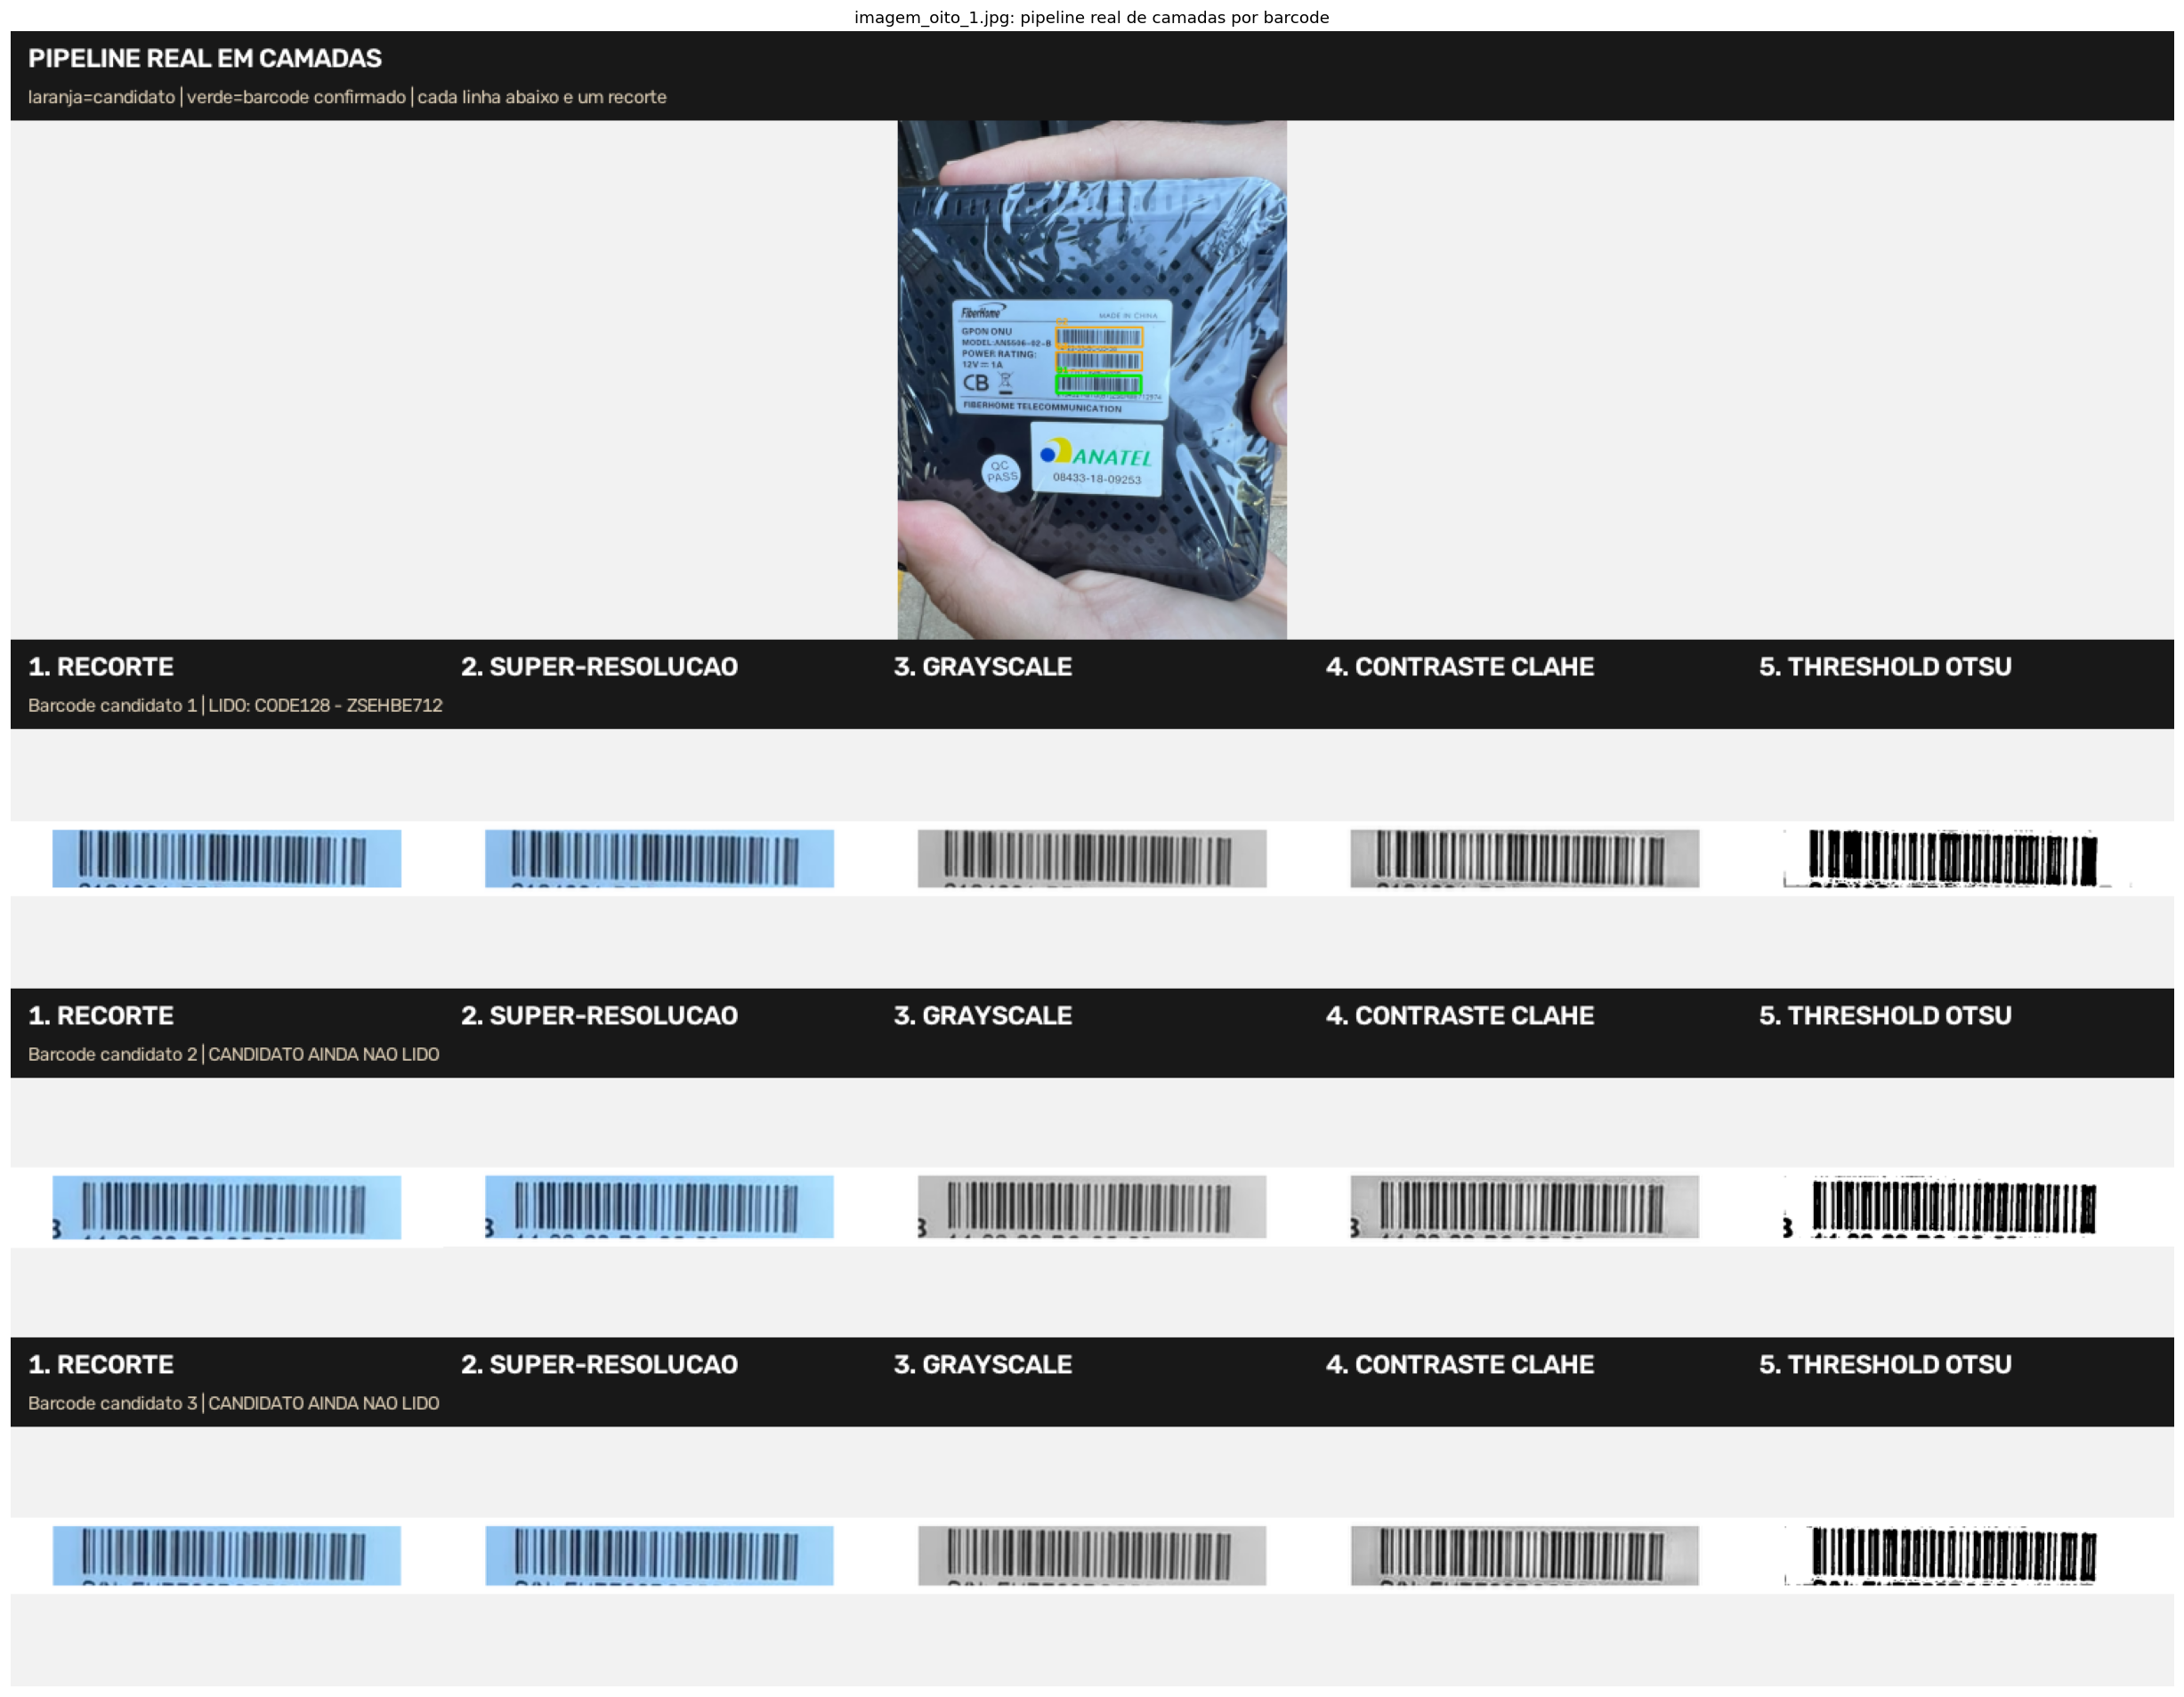

Concluído: 1 barcode(s) em 1.09 s


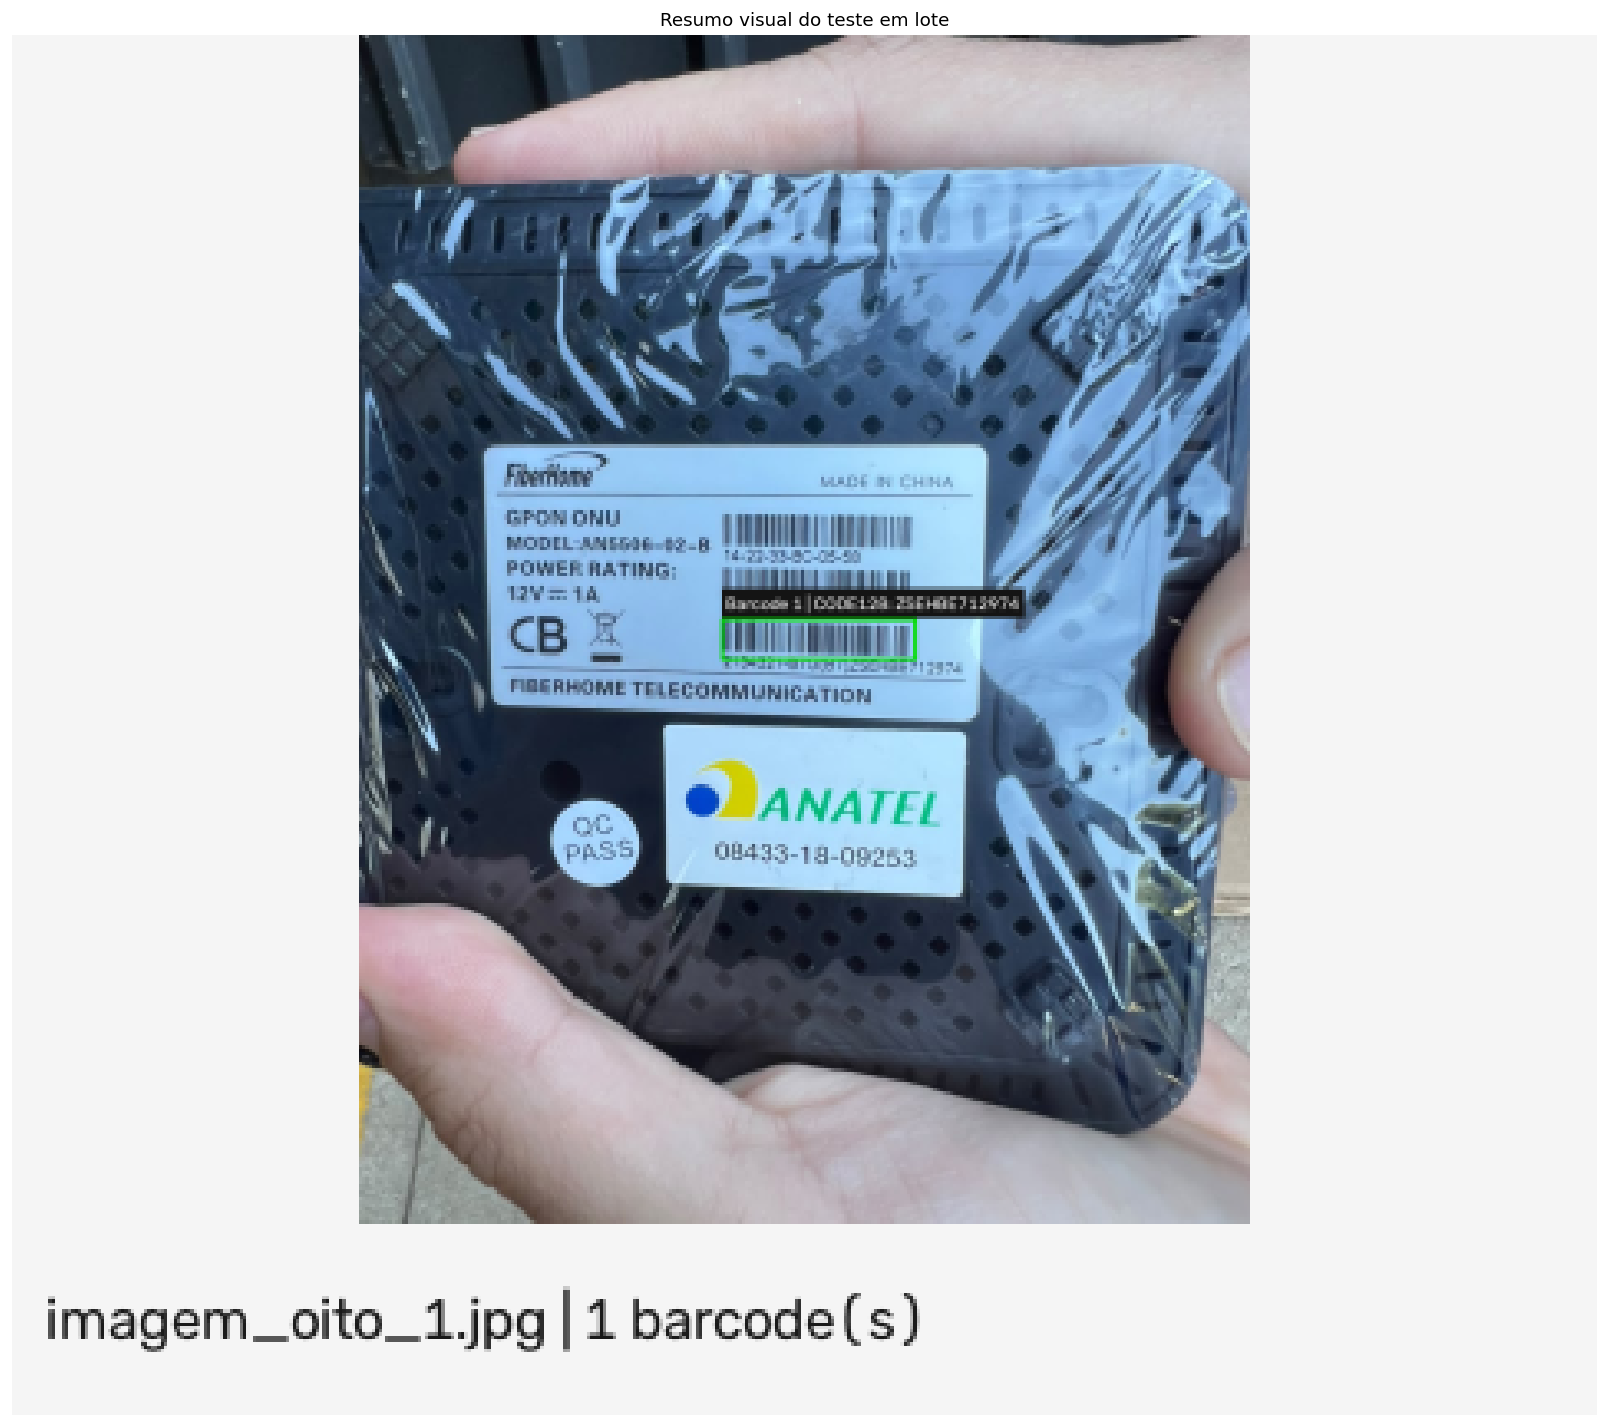


Relatório por imagem:


,arquivo,status,barcodes_lidos,tempo_segundos,tempo_leitura_global_s,tempo_roboflow_s,tempo_etiqueta_s,tempo_opencv_local_s,tempo_angular_s,tempo_pilha_visual_s,tempo_total_pipeline_s,largura,altura,erro
0,imagem_oito_1.jpg,ok,1,1.086,0.048,0.936,0.0,0.0,0.0,0.082,1.069,960,1280,


Detecções consolidadas:


,arquivo,barcode_id,valor,tipo,decodificado,x,y,largura,altura,signature_score,...,valid_row_ratio,direction_ratio,decoder,origem_candidato,confianca_roboflow,variante,recorte,votos_rotacao,angulos_confirmados,total_leituras
0,imagem_oito_1.jpg,1,ZSEHBE712974,CODE128,True,391,629,209,44,1.0,...,0.9211,3.6861,ZXing-C++,Roboflow barcode -> recorte -> leitura,0.9945,04_contraste_clahe,roboflow_l0.03_a-0.18,1,0,1


Teste concluído: 1 sucesso(s), 0 falha(s).
Tempo total: 2.94 segundos.
Resultados salvos em: barcode_results_20260814_144048
Arquivo ZIP criado: /content/barcode_results_20260814_144048.zip


In [56]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp",
}
MAX_ZIP_IMAGE_BYTES = 50 * 1024 * 1024

# Para lotes grandes, deixe as duas opções False. O notebook mostrará apenas
# um mosaico final. Ative-as ao investigar poucas imagens problemáticas.
BATCH_SHOW_LAYER_DEBUG = False
BATCH_SHOW_EACH_IMAGE = False
# A pilha visual é salva para todas as imagens e exibida para as primeiras.
BATCH_SHOW_FOCUS_STACK = True
BATCH_MAX_FOCUS_STACKS_TO_SHOW = 6


def decode_uploaded_image(content):
    data = np.frombuffer(content, dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image is None or image.size == 0:
        raise ValueError("O arquivo não pôde ser lido como imagem.")
    return image


def safe_name(filename):
    stem = Path(filename).stem
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", stem).strip("._")
    return stem or "imagem"


def unique_batch_filename(container_name, member_name, used_names):
    suffix = Path(member_name).suffix.lower()
    if member_name == container_name:
        raw_stem = Path(member_name).stem
    else:
        zip_stem = Path(container_name).stem
        member_stem = str(Path(member_name).with_suffix(""))
        raw_stem = f"{zip_stem}__{member_stem}"
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", raw_stem).strip("._")
    stem = stem or "imagem"
    candidate = f"{stem}{suffix}"
    counter = 2
    while candidate.lower() in used_names:
        candidate = f"{stem}_{counter}{suffix}"
        counter += 1
    used_names.add(candidate.lower())
    return candidate


def collect_batch_images(uploaded_files):
    # Aceita imagens individuais e ZIPs sem extrair arquivos no sistema.
    images = {}
    ignored = []
    used_names = set()
    for container_name, content in uploaded_files.items():
        suffix = Path(container_name).suffix.lower()
        if suffix in IMAGE_EXTENSIONS:
            filename = unique_batch_filename(
                container_name, container_name, used_names
            )
            images[filename] = bytes(content)
            continue
        if suffix != ".zip":
            ignored.append((container_name, "extensão não suportada"))
            continue
        try:
            with ZipFile(io.BytesIO(bytes(content))) as archive:
                for info in archive.infolist():
                    member_name = info.filename
                    member_suffix = Path(member_name).suffix.lower()
                    if info.is_dir() or member_suffix not in IMAGE_EXTENSIONS:
                        continue
                    if info.file_size > MAX_ZIP_IMAGE_BYTES:
                        ignored.append((
                            f"{container_name}:{member_name}",
                            "imagem maior que 50 MB",
                        ))
                        continue
                    filename = unique_batch_filename(
                        container_name, member_name, used_names
                    )
                    images[filename] = archive.read(info)
        except (BadZipFile, OSError) as error:
            ignored.append((container_name, f"ZIP inválido: {error}"))
    return images, ignored


def create_batch_contact_sheet(items, columns=3, tile_width=480):
    if not items:
        return None
    columns = max(1, min(columns, len(items)))
    image_height = 360
    label_height = 58
    tile_height = image_height + label_height
    rows = int(math.ceil(len(items) / columns))
    sheet = np.full(
        (rows * tile_height, columns * tile_width, 3),
        245, dtype=np.uint8,
    )
    for index, (filename, image, barcode_count) in enumerate(items):
        row, column = divmod(index, columns)
        height, width = image.shape[:2]
        scale = min(tile_width / max(width, 1), image_height / max(height, 1))
        resized = cv2.resize(
            image,
            (max(1, int(round(width * scale))), max(1, int(round(height * scale)))),
            interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC,
        )
        y0 = row * tile_height + (image_height - resized.shape[0]) // 2
        x0 = column * tile_width + (tile_width - resized.shape[1]) // 2
        sheet[y0:y0 + resized.shape[0], x0:x0 + resized.shape[1]] = resized
        label = f"{filename[:48]} | {barcode_count} barcode(s)"
        cv2.putText(
            sheet, label,
            (column * tile_width + 10, row * tile_height + image_height + 35),
            cv2.FONT_HERSHEY_SIMPLEX, 0.58, (25, 25, 25), 1, cv2.LINE_AA,
        )
    return sheet


uploaded_raw = files.upload()
if not uploaded_raw:
    raise ValueError("Nenhuma imagem ou ZIP foi enviado.")

uploaded, ignored_uploads = collect_batch_images(uploaded_raw)
del uploaded_raw
if not uploaded:
    raise ValueError("Nenhuma imagem compatível foi encontrada no envio.")

print(f"Imagens encontradas para o teste: {len(uploaded)}")
for ignored_name, reason in ignored_uploads:
    print(f"Ignorado: {ignored_name} ({reason})")

run_directory = Path(
    f"barcode_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
run_directory.mkdir(parents=True, exist_ok=False)

all_tables = []
run_results = {}
batch_rows = []
preview_items = []
batch_start = perf_counter()
total_images = len(uploaded)

for image_index, (filename, content) in enumerate(uploaded.items(), start=1):
    print(f"\n[{image_index}/{total_images}] Analisando: {filename}")
    image_start = perf_counter()
    try:
        image = decode_uploaded_image(content)
        regions, annotated, table, visual_stack = analyze_barcode_image(
            image, filename,
            show_debug=BATCH_SHOW_LAYER_DEBUG,
            show_output=BATCH_SHOW_EACH_IMAGE,
        )
    except Exception as error:
        elapsed = perf_counter() - image_start
        print(f"Falha em {filename}: {type(error).__name__}: {error}")
        batch_rows.append({
            "arquivo": filename, "status": "erro",
            "barcodes_lidos": 0, "tempo_segundos": round(elapsed, 3),
            "largura": None, "altura": None,
            "erro": f"{type(error).__name__}: {error}",
        })
        continue

    elapsed = perf_counter() - image_start
    pipeline_timings = table.attrs.get("pipeline_timings", {})
    all_tables.append(table)
    run_results[filename] = regions
    preview_items.append((filename, annotated, len(regions)))
    batch_rows.append({
        "arquivo": filename, "status": "ok",
        "barcodes_lidos": len(regions),
        "tempo_segundos": round(elapsed, 3),
        **{
            key: round(float(value), 3)
            for key, value in pipeline_timings.items()
        },
        "largura": image.shape[1], "altura": image.shape[0],
        "erro": "",
    })

    image_directory = run_directory / safe_name(filename)
    roi_directory = image_directory / "validated_barcode_rois"
    roi_directory.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(
        str(image_directory / "final_result_annotated.png"), annotated
    )
    if visual_stack is not None:
        cv2.imwrite(
            str(image_directory / "visual_barcode_layer_pipeline.jpg"),
            visual_stack, [cv2.IMWRITE_JPEG_QUALITY, 92],
        )
        if (
            BATCH_SHOW_FOCUS_STACK
            and image_index <= BATCH_MAX_FOCUS_STACKS_TO_SHOW
        ):
            show_bgr(
                visual_stack,
                f"{filename}: pipeline real de camadas por barcode",
                figsize=(22, 16),
            )
    for region in regions:
        value = safe_name(region["value"] or "not_decoded")
        roi_name = f"barcode_{region['barcode_id']}_{value}.png"
        cv2.imwrite(str(roi_directory / roi_name), region["decode_roi"])
    table.to_csv(image_directory / "detections.csv", index=False)
    print(f"Concluído: {len(regions)} barcode(s) em {elapsed:.2f} s")

summary = (
    pd.concat(all_tables, ignore_index=True)
    if all_tables else pd.DataFrame()
)
batch_report = pd.DataFrame(batch_rows)
summary.to_csv(run_directory / "all_detections.csv", index=False)
batch_report.to_csv(run_directory / "batch_report.csv", index=False)

contact_sheet = create_batch_contact_sheet(preview_items)
if contact_sheet is not None:
    cv2.imwrite(str(run_directory / "batch_contact_sheet.jpg"), contact_sheet)
    show_bgr(contact_sheet, "Resumo visual do teste em lote", figsize=(18, 12))

print("\nRelatório por imagem:")
display(batch_report)
print("Detecções consolidadas:")
display(summary)

archive_path = shutil.make_archive(
    str(run_directory), "zip", root_dir=run_directory
)
batch_elapsed = perf_counter() - batch_start
successful = int((batch_report["status"] == "ok").sum())
failed = int((batch_report["status"] == "erro").sum())
print(f"Teste concluído: {successful} sucesso(s), {failed} falha(s).")
print(f"Tempo total: {batch_elapsed:.2f} segundos.")
print(f"Resultados salvos em: {run_directory}")
print(f"Arquivo ZIP criado: {archive_path}")


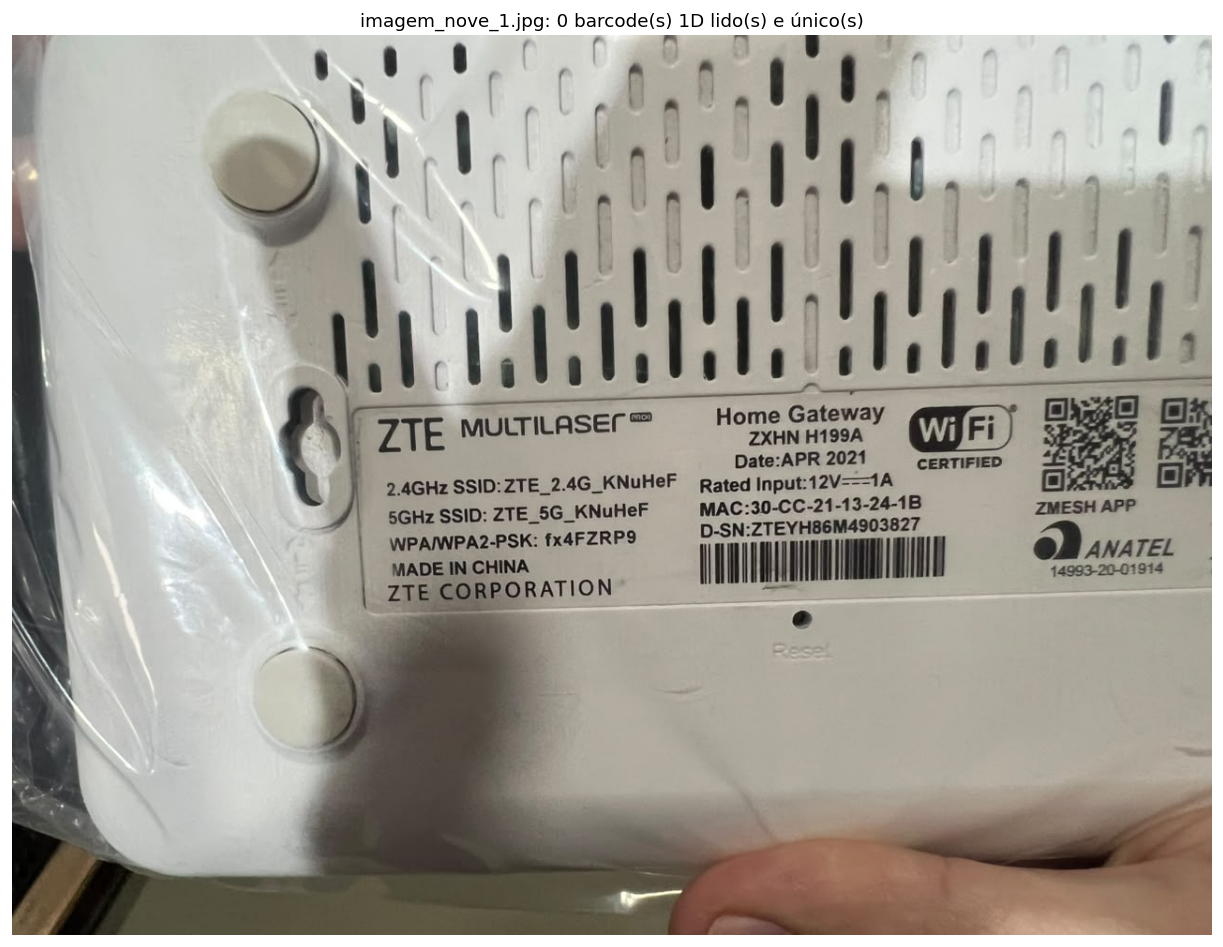

""


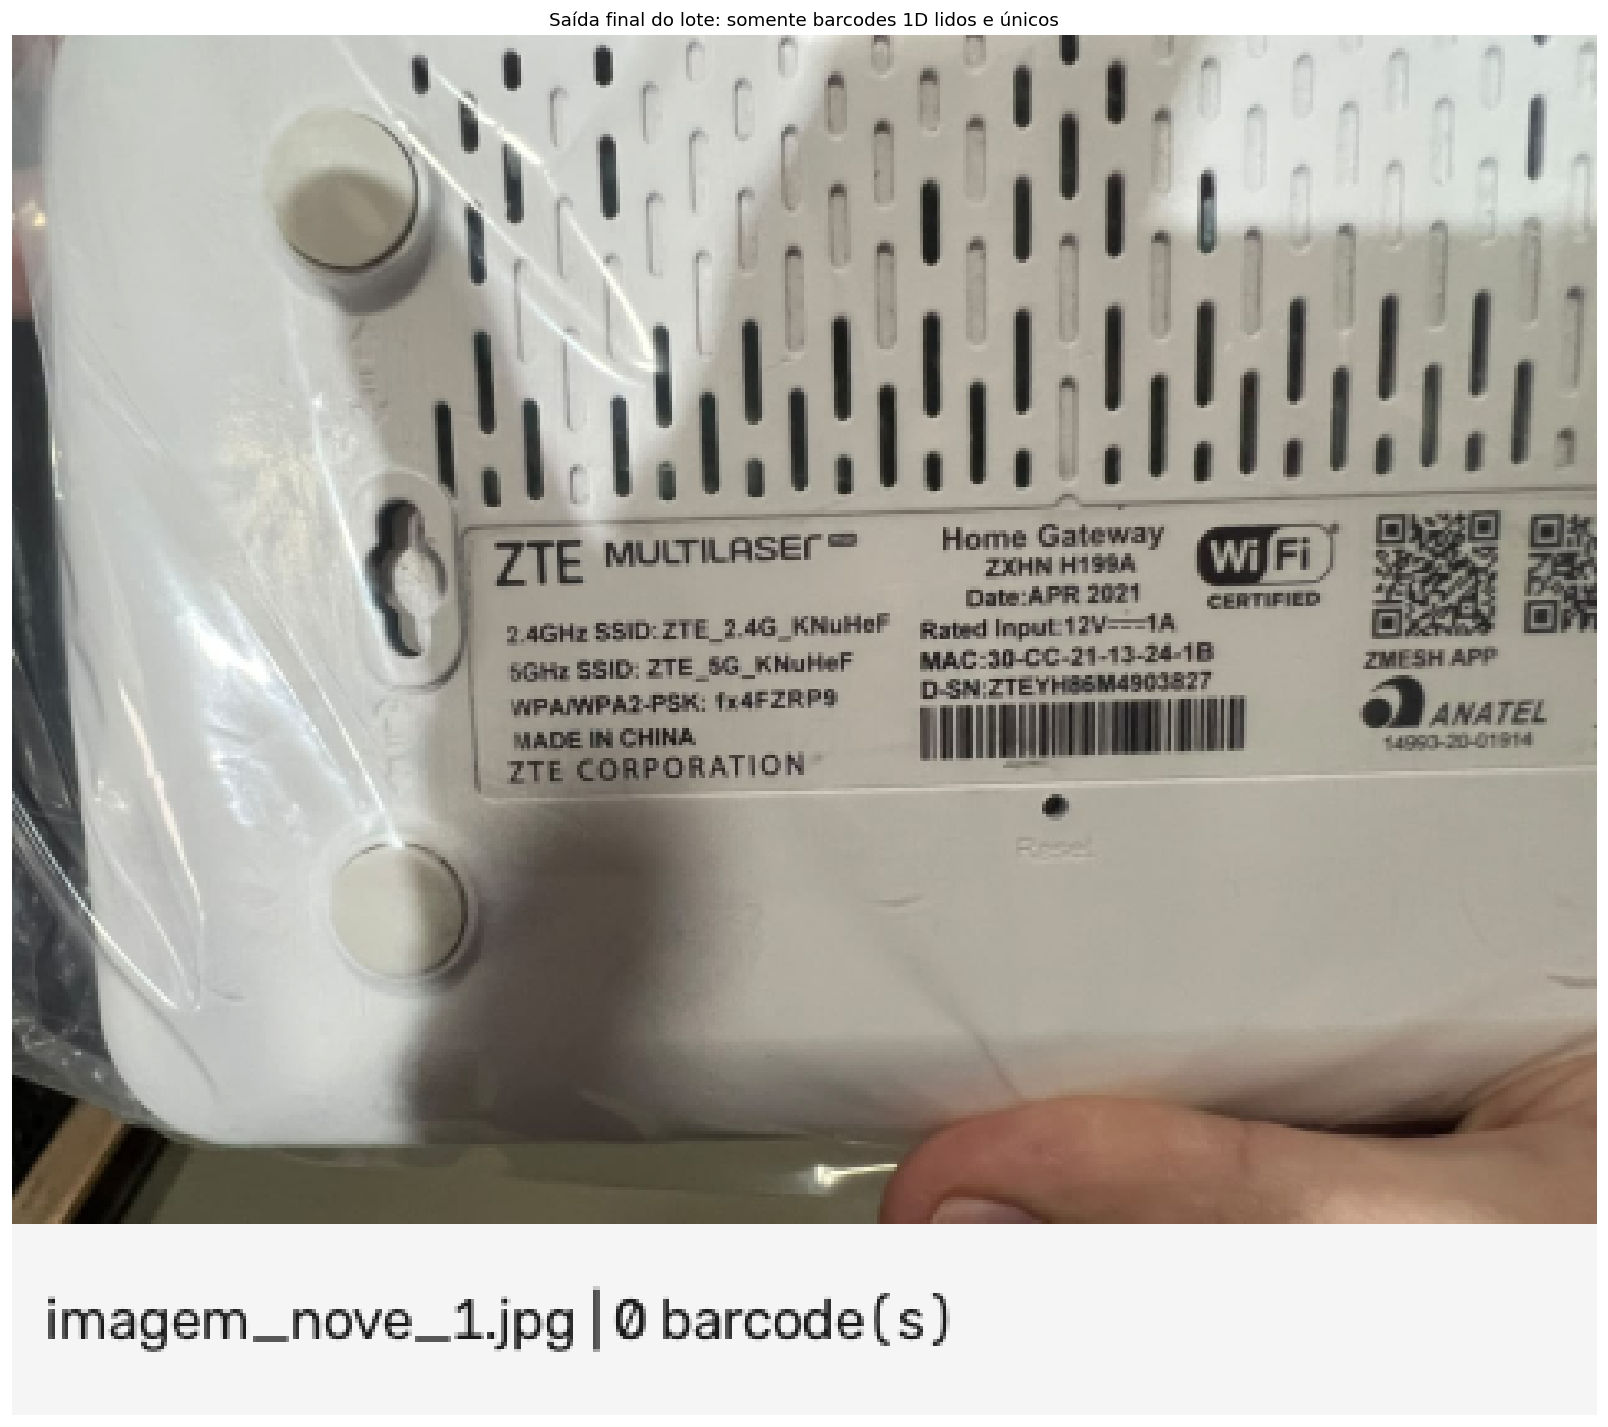

Saída final salva em: only_decoded_barcodes_20260814_143927
ZIP final criado: /content/only_decoded_barcodes_20260814_143927.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
# SAÍDA FINAL ESTRITA: SOMENTE BARCODES 1D EFETIVAMENTE LIDOS
if "uploaded" not in globals() or "run_results" not in globals():
    raise RuntimeError("Execute primeiro a célula de upload e análise.")

FINAL_1D_TYPES = {
    "CODABAR", "CODE39", "CODE93", "CODE128",
    "DATABAR", "DATABAREXP", "DATABAREXPANDED",
    "DATABARLIMITED", "EAN2", "EAN5", "EAN8", "EAN13",
    "I25", "ITF", "ISBN10", "ISBN13",
    "UPCA", "UPCE",
}


def final_type_name(value):
    return re.sub(r"[^A-Z0-9]+", "", str(value).upper())


def final_unique_barcodes(regions):
    # A melhor região de cada par tipo+valor é mantida; todo o resto é descartado.
    ordered = sorted(
        regions,
        key=lambda item: item.get("signature", {}).get("score", 0.0),
        reverse=True,
    )
    unique = []
    seen = set()
    for region in ordered:
        barcode_type = final_type_name(region.get("type", ""))
        value = str(region.get("value", "")).strip()
        if not region.get("decoded") or not value:
            continue
        if barcode_type not in FINAL_1D_TYPES:
            continue
        key = (barcode_type, value)
        if key in seen:
            continue
        seen.add(key)
        unique.append(region)

    unique.sort(key=lambda item: (item["bbox"][1], item["bbox"][0]))
    for barcode_id, region in enumerate(unique, start=1):
        region["final_barcode_id"] = barcode_id
    return unique


def draw_only_final_barcodes(image, regions):
    output = image.copy()
    image_height, image_width = image.shape[:2]
    line_width = max(2, int(round(max(image_height, image_width) / 600)))
    font_scale = max(0.5, min(0.85, image_width / 1400.0))
    thickness = max(1, line_width - 1)

    for region in regions:
        box = np.asarray(region["box"], dtype=np.int32)
        cv2.polylines(output, [box], True, (0, 220, 0), line_width, cv2.LINE_AA)
        x, y, _, h = region["bbox"]
        label = (
            f"Barcode {region['final_barcode_id']} | "
            f"{region['type']}: {region['value']}"
        )
        (text_width, text_height), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
        )
        text_x = int(np.clip(x, 0, max(0, image_width - text_width - 10)))
        text_y = y - 10 if y > text_height + 16 else min(
            image_height - 8, y + h + text_height + 12
        )
        cv2.rectangle(
            output,
            (text_x, max(0, text_y - text_height - 6)),
            (
                min(image_width - 1, text_x + text_width + 8),
                min(image_height - 1, text_y + baseline + 4),
            ),
            (20, 20, 20),
            -1,
        )
        cv2.putText(
            output, label, (text_x + 4, text_y),
            cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255),
            thickness, cv2.LINE_AA,
        )
    return output


final_directory = Path(
    f"only_decoded_barcodes_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
final_directory.mkdir(parents=True, exist_ok=False)
final_rows = []
final_images = {}
final_preview_items = []
FINAL_SHOW_EACH_IMAGE = len(run_results) <= 6

for filename, regions in run_results.items():
    content = uploaded[filename]
    original = decode_uploaded_image(content)
    unique_regions = final_unique_barcodes(regions)
    final_image = draw_only_final_barcodes(original, unique_regions)
    final_images[filename] = final_image
    final_preview_items.append((filename, final_image, len(unique_regions)))

    output_name = f"{safe_name(filename)}_only_decoded_barcodes.png"
    cv2.imwrite(str(final_directory / output_name), final_image)
    if FINAL_SHOW_EACH_IMAGE:
        show_bgr(
            final_image,
            f"{filename}: {len(unique_regions)} barcode(s) 1D lido(s) e único(s)",
        )

    for region in unique_regions:
        x, y, w, h = region["bbox"]
        final_rows.append({
            "arquivo": filename,
            "barcode_id": region["final_barcode_id"],
            "tipo": region["type"],
            "valor": region["value"],
            "x": x, "y": y, "largura": w, "altura": h,
            "decoder": region["decoder"],
            "origem_candidato": region.get("source", ""),
            "confianca_roboflow": region.get("roboflow_confidence"),
            "votos_rotacao": region.get("rotation_votes", 0),
            "angulos_confirmados": ",".join(
                map(str, region.get("rotation_angles", []))
            ),
        })

final_summary = pd.DataFrame(final_rows)
final_summary.to_csv(final_directory / "only_decoded_barcodes.csv", index=False)
display(final_summary)

final_contact_sheet = create_batch_contact_sheet(final_preview_items)
if final_contact_sheet is not None:
    cv2.imwrite(
        str(final_directory / "only_decoded_barcodes_contact_sheet.jpg"),
        final_contact_sheet,
    )
    show_bgr(
        final_contact_sheet,
        "Saída final do lote: somente barcodes 1D lidos e únicos",
        figsize=(18, 12),
    )

final_archive = shutil.make_archive(
    str(final_directory), "zip", root_dir=final_directory
)
print(f"Saída final salva em: {final_directory}")
print(f"ZIP final criado: {final_archive}")
files.download(final_archive)
